# Integrantes
- Daniel Diab
- Laura Martinez

# 1. Exploración de Datos
En esta sección se realiza un proceso de perfilamiento del conjunto de datos con el objetivo de comprender su estructura, distribución y calidad. Este análisis permite identificar posibles problemas que puedan afectar el desempeño del modelo de regresión lineal, tales como valores faltantes, duplicados, inconsistencias y errores de validez.


## 1.1. Importar librerías

In [317]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## 1.2. Cargar Datos

Se cargan los datos desde el archivo csv, pero igual se hace una copia para no modificar los originales.

In [318]:
df = pd.read_csv('./data.csv', sep=',', header=0)
datos = df.copy()

Para tener una primera visión de los datos, podemos ver los primeros 5 registros:

In [319]:
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


También, podemos ver cuantas columnas (variables) y filas (registros) hay:

In [320]:
datos.shape

(1639, 24)

Entonces, vemos que hay 1639 registros y 24 variables. La variable objetivo del modelo es CVD Risk Score, la cual es numérica continua y representa el nivel estimado de riesgo cardiovascular.

El resto de las variables corresponden a información demográfica, antropométrica, clínica y de estilo de vida.

Además, podemos conocer el tipo de dato de cada una de las variables:

In [321]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

La revisión inicial de los tipos de datos permite verificar la coherencia estructural del conjunto. Se observa que varias variables numéricas están correctamente identificadas como float64, mientras que las variables categóricas se encuentran como object.

Sin embargo, es necesario contrastar estos tipos con lo establecido en el diccionario de datos para validar que cumplan con el esquema esperado. Esta verificación forma parte del análisis de validez estructural del dataset que haremos mas adelante.

## 1.3. Diccionario de Datos

Ahora, revisemos el diccionario de datos con el fin de comprender la definición de cada variable, su tipo esperado (numérico, categórico, fecha), su unidad de medida y el dominio de valores permitido. Esta revisión es clave para evitar interpretaciones incorrectas y para establecer criterios claros de validación de calidad (por ejemplo, tipos correctos, rangos clínicamente posibles y categorías válidas).

In [322]:
dicccionario = pd.read_excel('./diccionario.xlsx')
pd.set_option('display.max_colwidth', None)
dicccionario

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arterial sistólica>/<Presión arterial diastólica>"""
9,Total Cholesterol (mg/dL),Float,Colesterol total


## 1.4. Descripción de los Datos

En esta sección se realiza un análisis descriptivo de las variables numéricas con el fin de comprender su comportamiento estadístico básico antes de avanzar hacia la preparación de datos. Este análisis permite identificar rangos, dispersión, posibles valores atípicos y coherencia general en las magnitudes observadas.

In [323]:
datos.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


A partir de las estadísticas descriptivas se identifican varios aspectos importantes en las variables numéricas del conjunto de datos.

En la variable Age, el promedio es de aproximadamente 46.8 años, lo cual es coherente con una población adulta. Sin embargo, el valor mínimo es 6.13 años, lo cual no coincide con el contexto del problema, que está enfocado en adultos. Esto sugiere que puede existir al menos un registro que no pertenece a la población objetivo o que fue ingresado incorrectamente.

En Weight (kg) y Height (m) los valores promedio parecen razonables. No obstante, al analizar el BMI, se observa un valor mínimo de 4.31, que es extremadamente bajo. El BMI se calcula como peso dividido por estatura al cuadrado. En adultos, valores por debajo de 15 ya se consideran clínicamente severos. Un BMI de 4.31 implicaría un peso extremadamente bajo para la estatura registrada, lo cual no es compatible con un adulto en condiciones normales. Por lo tanto, este valor probablemente corresponde a un error de registro o cálculo.

En las variables de laboratorio se detectan problemas aún más evidentes. Por ejemplo:

Total Cholesterol tiene un valor mínimo de -1.256

Estimated LDL tiene un valor mínimo de -92.055

El colesterol y el LDL no pueden ser negativos desde el punto de vista biológico, ya que representan concentraciones en sangre. Estos valores indican claramente un problema de calidad del dato, posiblemente causado por errores de digitación o medición.

También se observan valores muy bajos en HDL (0.008 mg/dL) y en Fasting Blood Sugar (15.306 mg/dL). Aunque no son negativos, son extremadamente bajos para un adulto y deberían revisarse para confirmar si corresponden a registros reales o errores.

En las variables de presión arterial (Systolic BP y Diastolic BP), los rangos en general parecen razonables. Sin embargo, una presión sistólica mínima de 49.9 mmHg es muy baja para un adulto y podría indicar un error o una condición clínica extrema que debería validarse.

Finalmente, la variable CVD Risk Score presenta valores negativos (mínimo de -20.05). Será necesario verificar si la escala del puntaje permite valores negativos o si estos registros representan errores.

En conclusión, aunque muchas variables presentan valores promedio coherentes, el análisis descriptivo revela la presencia de valores claramente inválidos (principalmente valores negativos en variables clínicas) y algunos valores extremos que requieren revisión. Estos hallazgos confirman la necesidad de realizar una etapa de preparación cuidadosa antes de construir el modelo de regresión.

## 1.5. Visualización de los Datos
En esta sección se complementa el análisis exploratorio mediante visualizaciones que permiten identificar la distribución de las variables, posibles valores atípicos y patrones generales en los datos.

### Numéricas

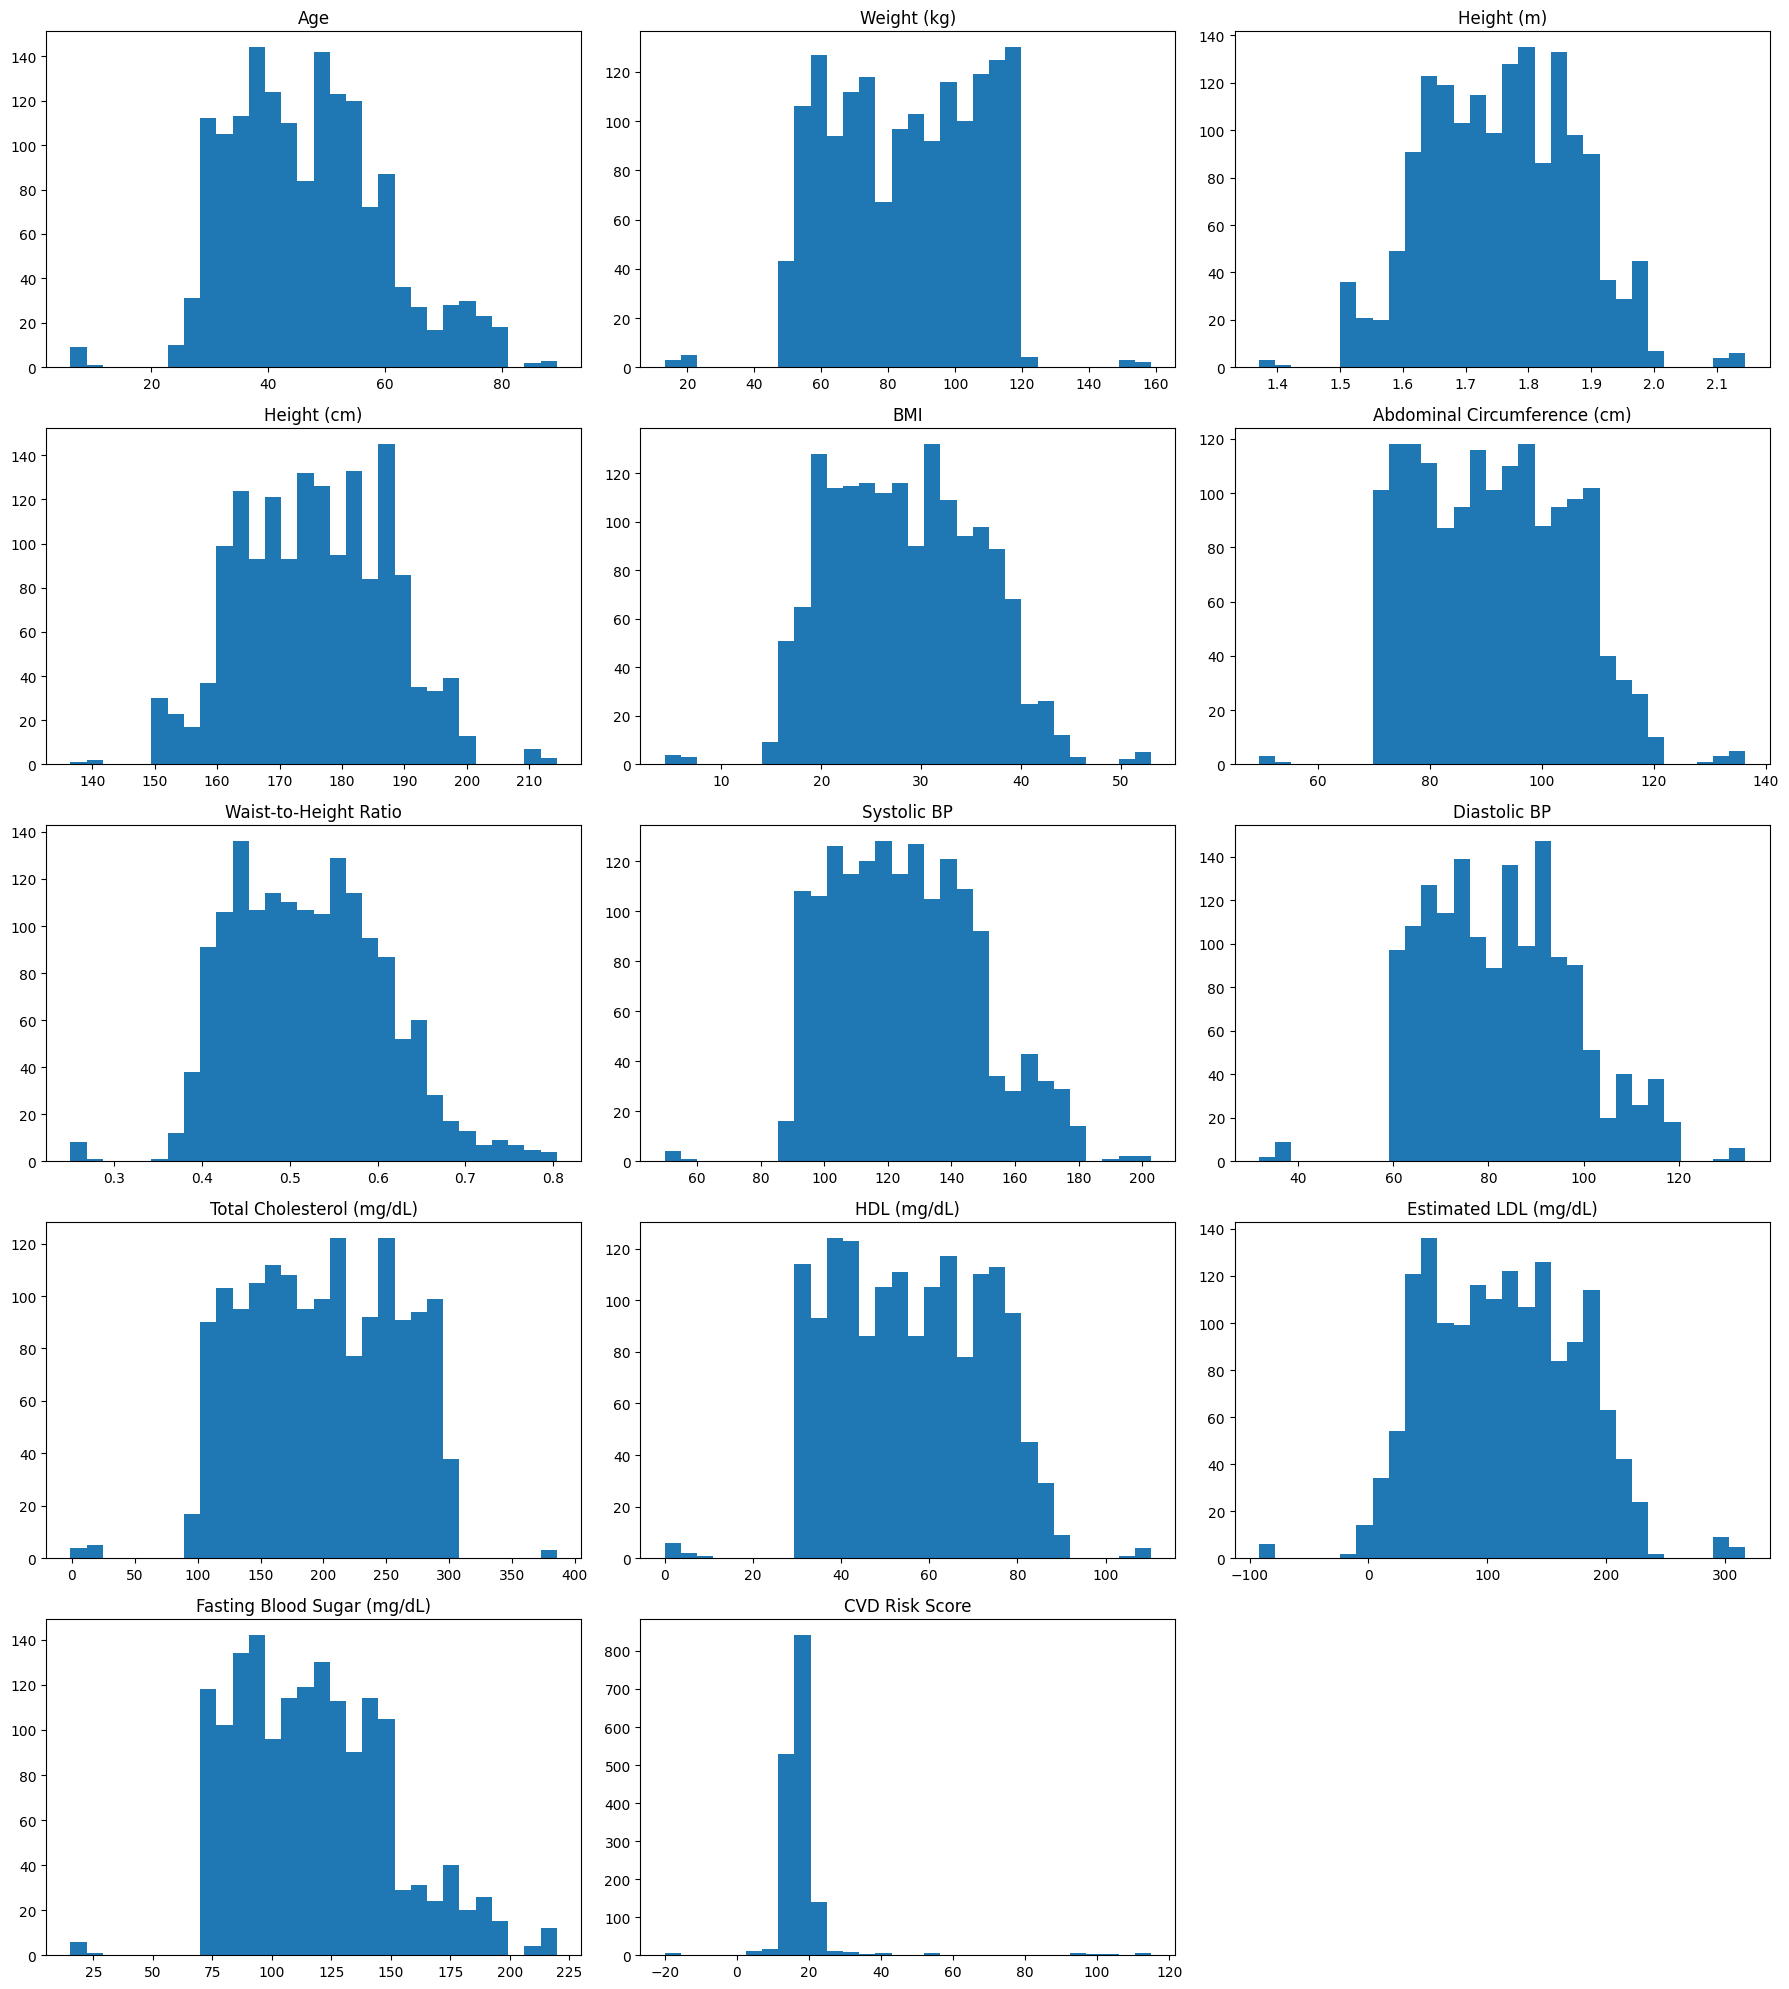

In [324]:
numericas = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "Height (cm)",
    "BMI",
    "Abdominal Circumference (cm)",
    "Waist-to-Height Ratio",
    "Systolic BP",
    "Diastolic BP",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "CVD Risk Score",
]

numericas = [c for c in numericas if c in datos.columns]

n = len(numericas)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(datos[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# ocultar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Las distribuciones muestran que la mayoría de las variables clínicas presentan un comportamiento concentrado en rangos plausibles para población adulta. Sin embargo, en varias de ellas aparecen valores que se separan claramente del grupo principal. En la variable Age, se observan registros por debajo de 10 años, lo cual resulta llamativo dado el contexto del estudio. En BMI, aparecen valores extremadamente bajos y otros muy elevados en comparación con el rango donde se concentra la mayoría de los datos. Algo similar ocurre en Estimated LDL, donde además de valores altos se observan valores negativos, que no tienen interpretación clínica directa.

En las variables de presión arterial, tanto Systolic BP como Diastolic BP, la mayoría de los valores se concentra en rangos habituales, pero existen registros muy alejados del centro de la distribución, tanto por debajo como por encima. Lo mismo sucede en Total Cholesterol y Fasting Blood Sugar, donde aparecen valores considerablemente más extremos que el grupo principal. Estos comportamientos no dominan la distribución, pero sí representan casos que deben revisarse antes del modelado.

La variable CVD Risk Score muestra una alta concentración en valores bajos y una dispersión hacia valores altos, lo que sugiere una distribución asimétrica. Además, aparecen algunos valores negativos, lo cual debe analizarse en función de la definición de la escala del puntaje.

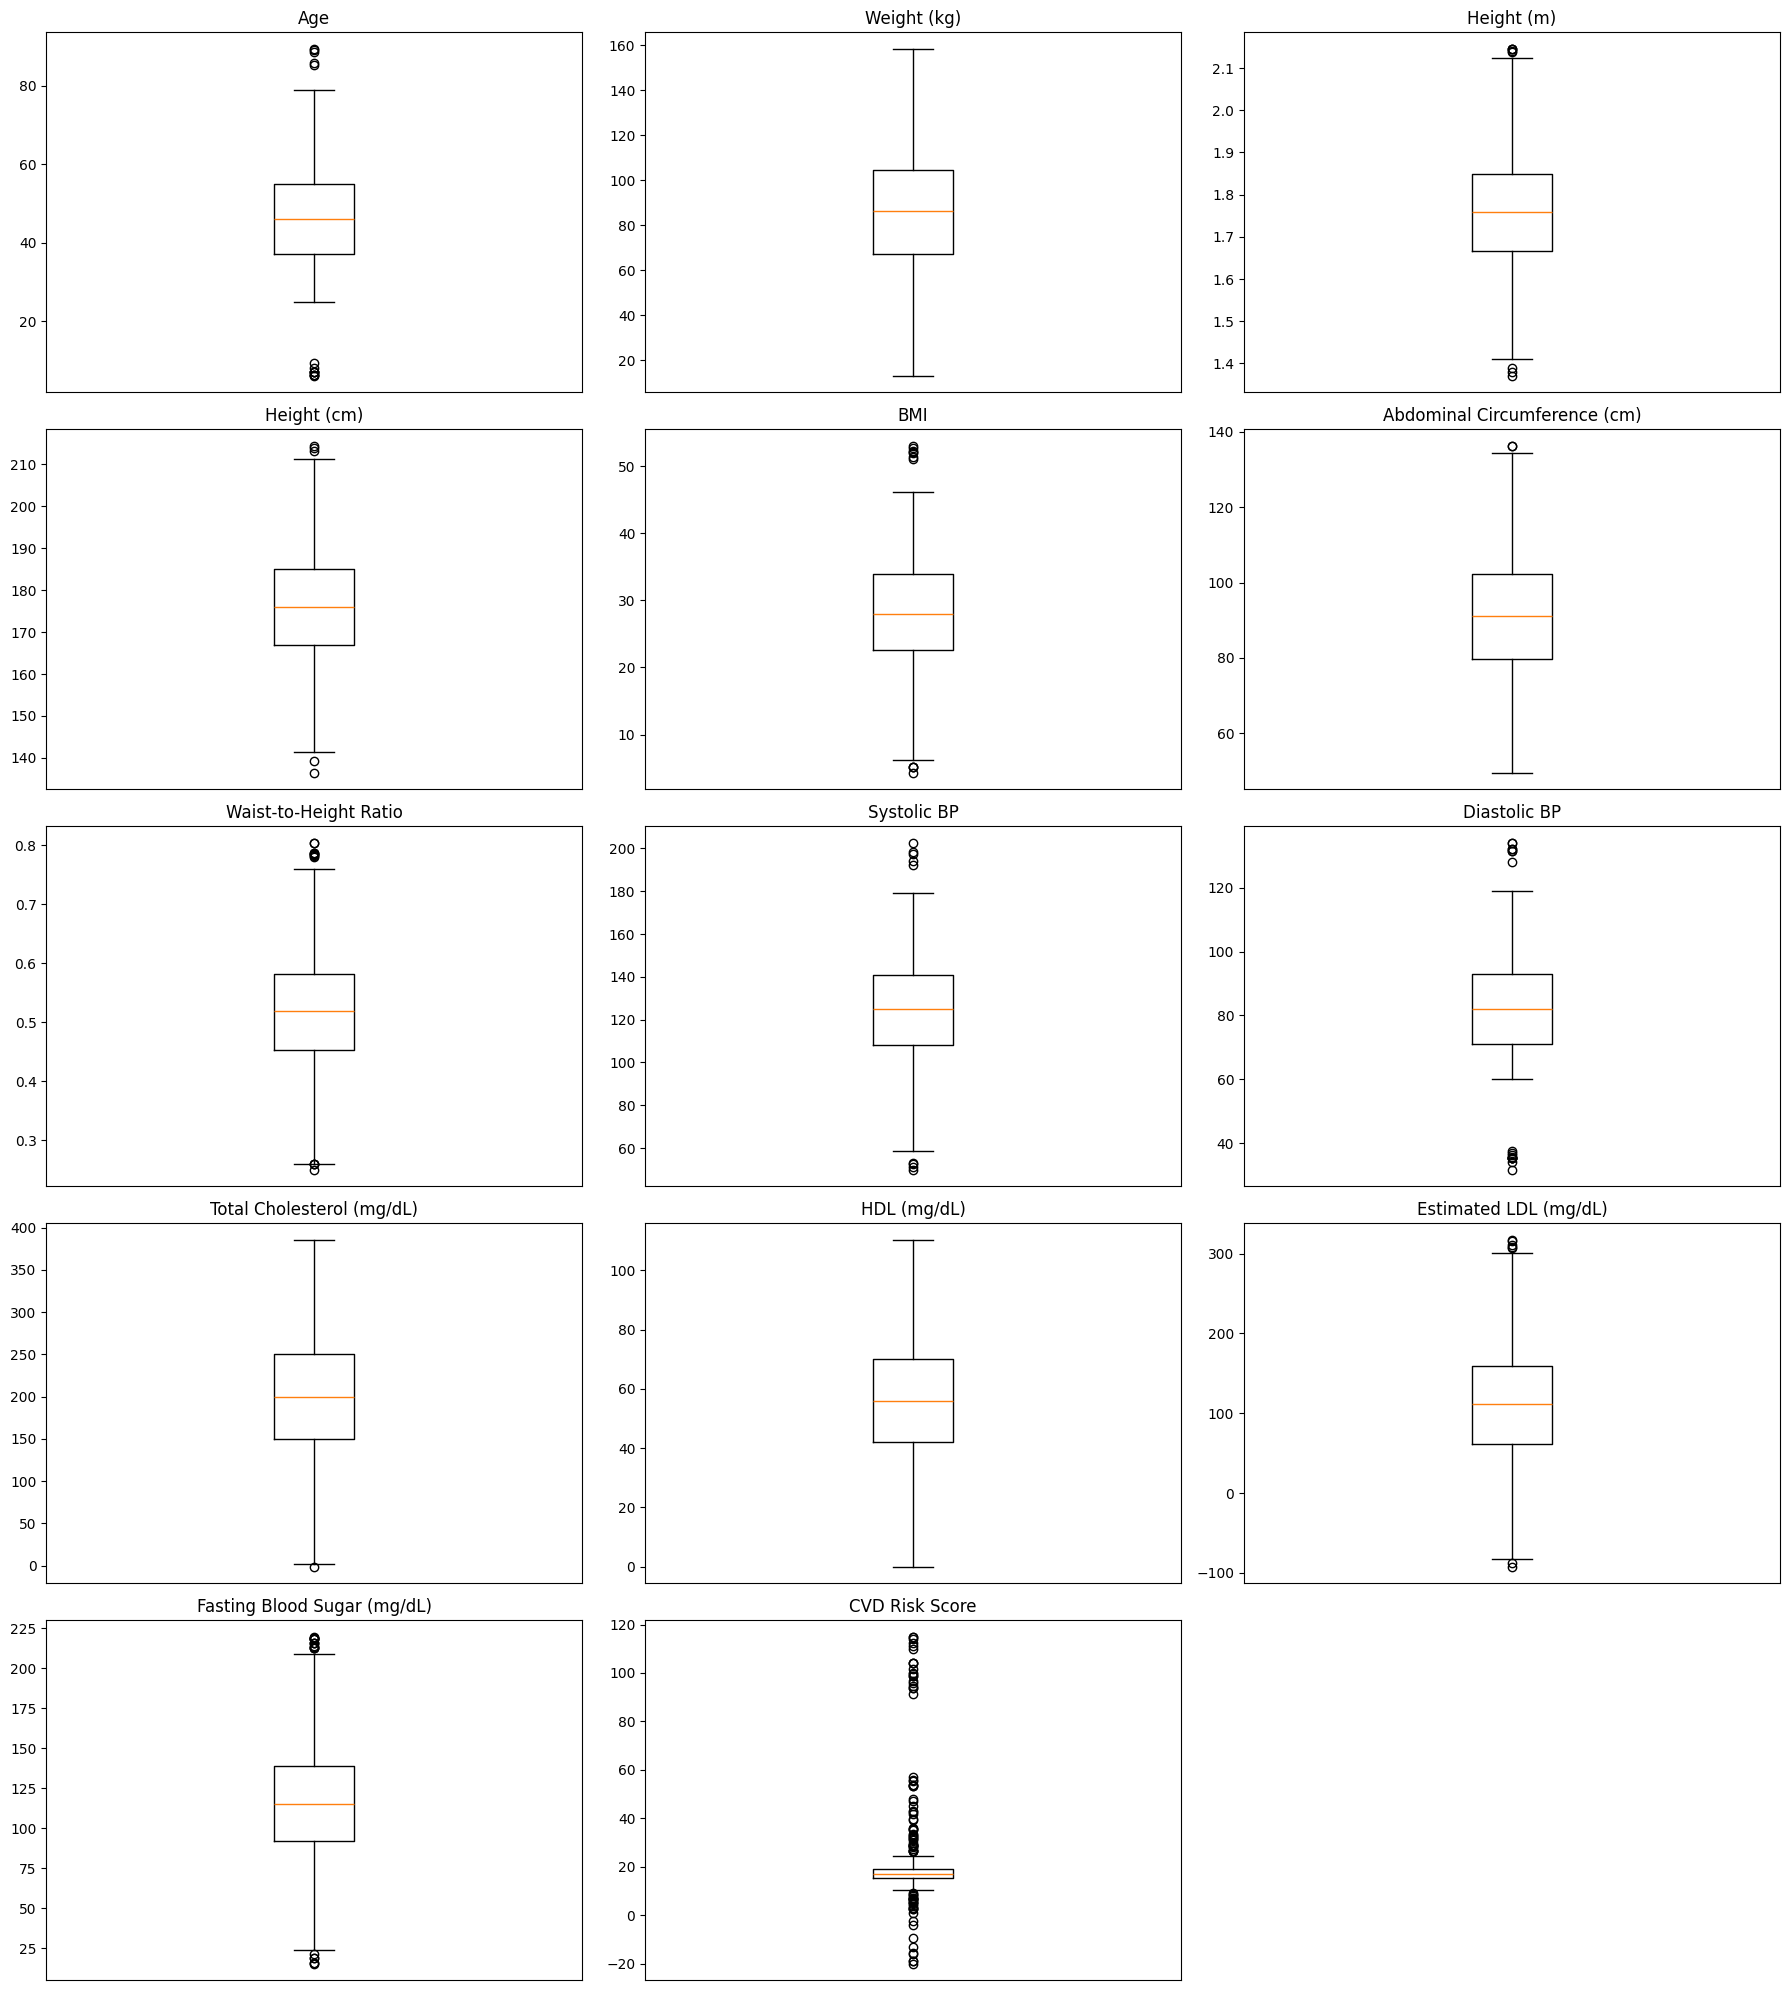

In [325]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].boxplot(datos[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Los diagramas de caja permiten visualizar con mayor claridad la presencia de valores alejados del rango intercuartílico. En BMI, Estimated LDL, CVD Risk Score y las variables de presión arterial se observan varios puntos fuera del rango central, lo que indica que estas variables contienen valores considerablemente distintos al comportamiento típico de la mayoría de los registros.

En el caso de Age, los valores bajos quedan claramente separados del resto de la distribución. En LDL y colesterol total, también se observan valores extremos que se distancian del núcleo principal de los datos. En conjunto, los boxplots confirman que varias variables presentan dispersión relevante y casos extremos que deberán tratarse cuidadosamente en la etapa de preparación de datos.

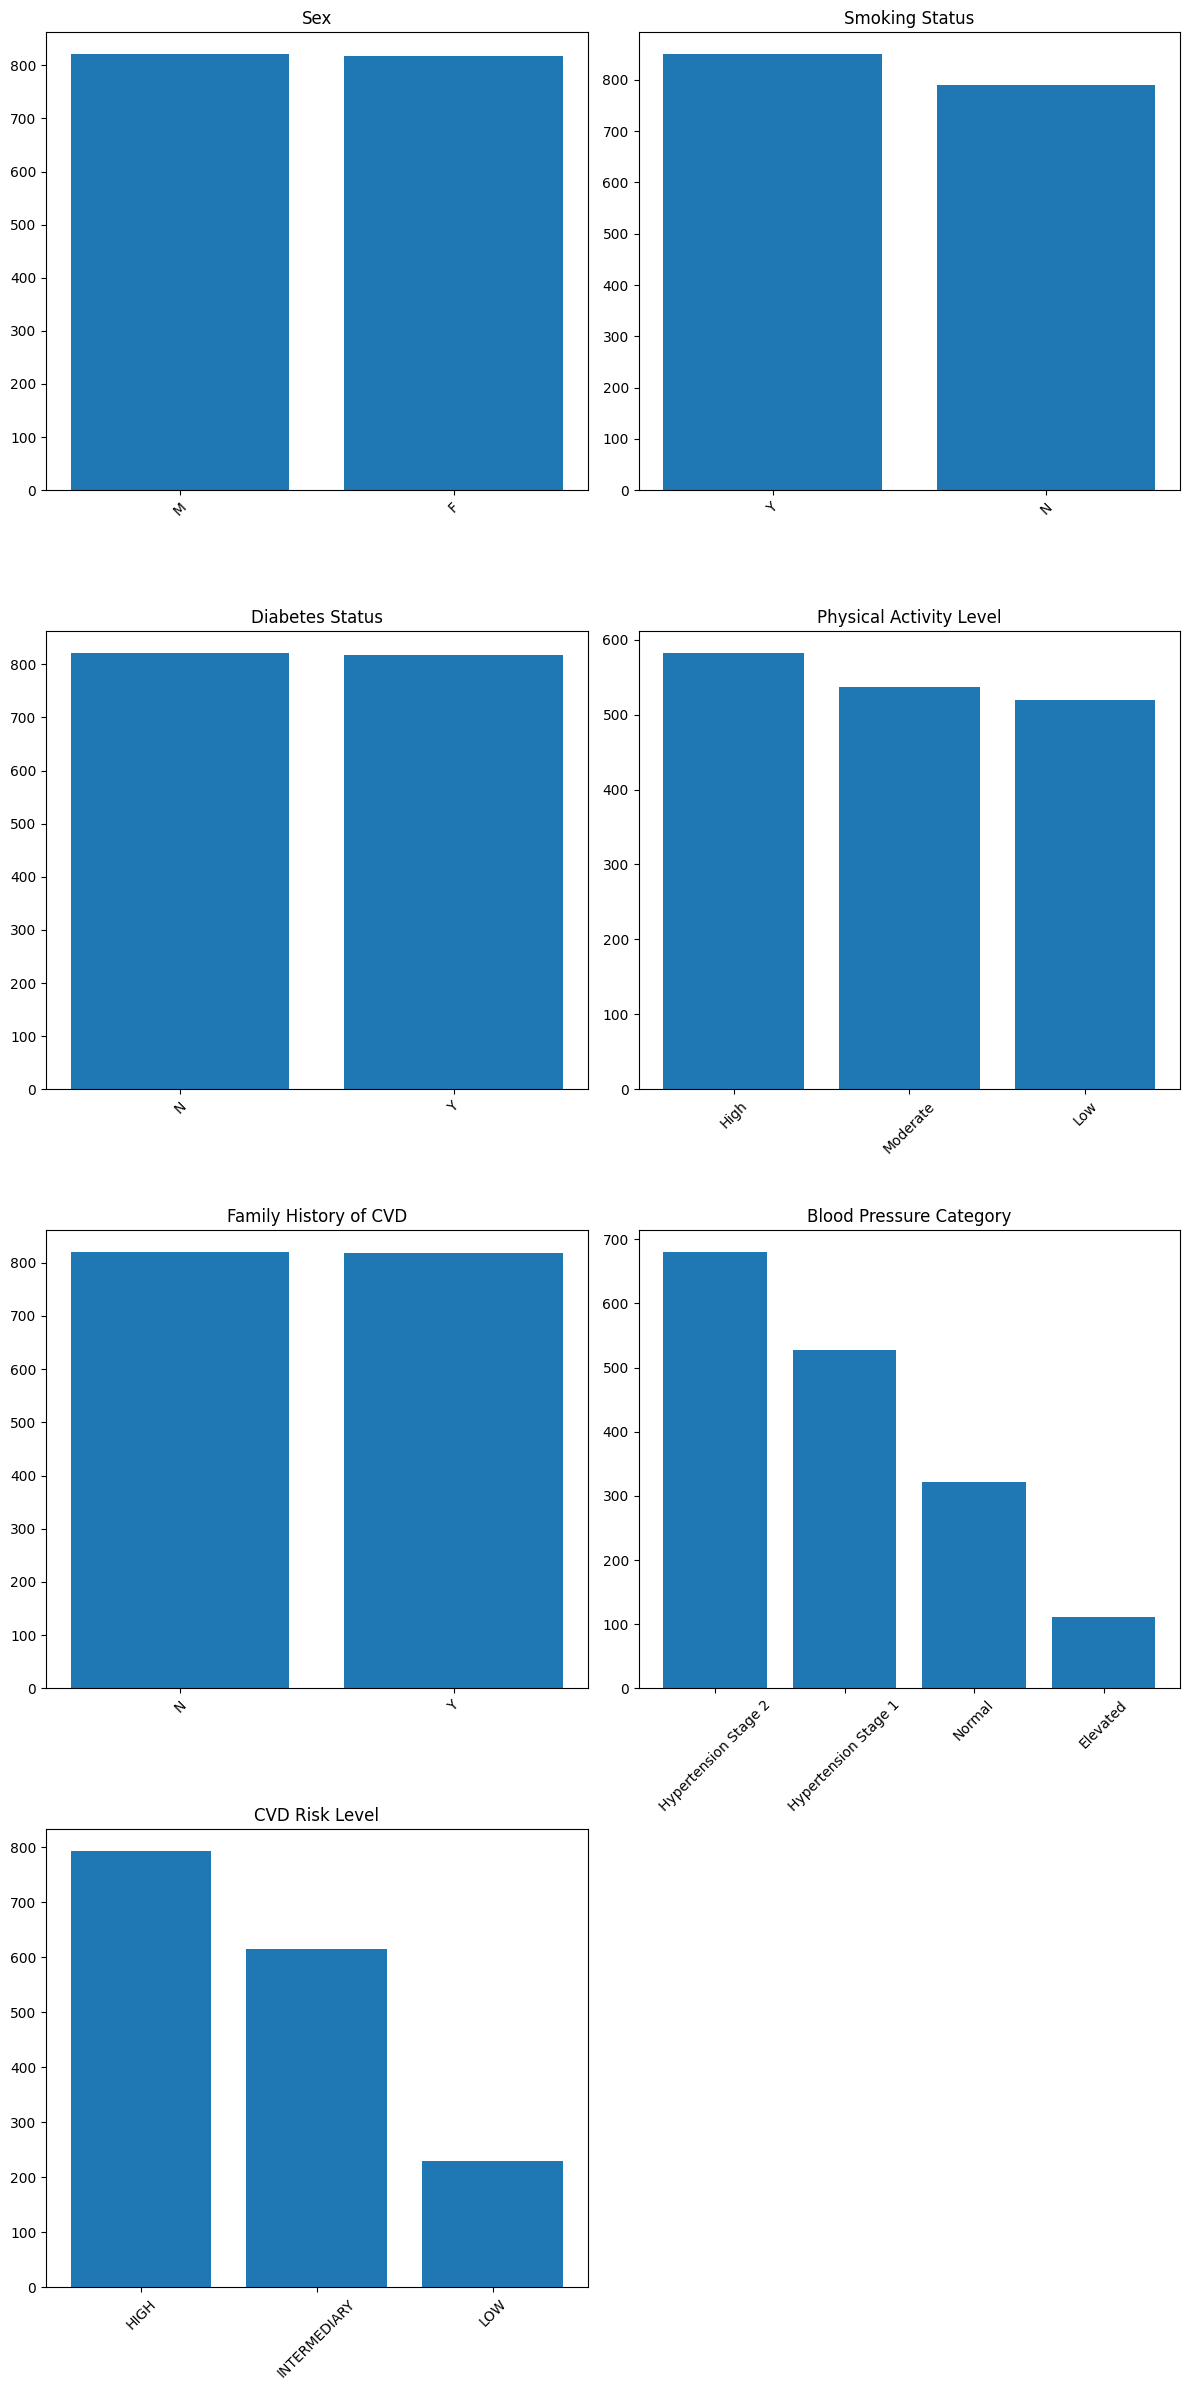

In [326]:
categoricas = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category",
    "CVD Risk Level",
]
categoricas = [c for c in categoricas if c in datos.columns]

n = len(categoricas)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    vc = datos[col].astype(str).str.strip().value_counts(dropna=False)
    axes[i].bar(vc.index.astype(str), vc.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

En las variables binarias Sex, Smoking Status, Diabetes Status y Family History of CVD, la distribución es bastante equilibrada entre sus dos categorías. No se observa un desbalance fuerte en ninguna de ellas.

En Physical Activity Level, las tres categorías (High, Moderate, Low) presentan frecuencias similares, aunque la categoría High tiene una ligera mayor representación. La variable no muestra concentración extrema en una sola categoría, lo que permite mantener variabilidad informativa.

En Blood Pressure Category, la mayor proporción se encuentra en Hypertension Stage 2, seguida de Hypertension Stage 1. Las categorías Normal y Elevated tienen menor representación. Esto indica que una parte importante del conjunto de datos corresponde a niveles elevados de presión arterial, lo cual es coherente con un contexto de análisis de riesgo cardiovascular.

En CVD Risk Level, la categoría HIGH es la más frecuente, seguida de INTERMEDIARY, mientras que LOW es la menos representada. Esto sugiere que el conjunto de datos tiene mayor presencia de individuos clasificados en niveles de riesgo medio y alto.

## 1.6. Problemas de Calidad
### 1.6.1. Completitud
Se evaluó la completitud del conjunto de datos mediante el conteo de valores faltantes por variable.

In [327]:
faltantes = datos.isnull().sum()

tabla_faltantes = pd.DataFrame({
    'Conteo': faltantes,
    'Porcentaje': (faltantes / len(datos)) * 100
})

tabla_faltantes = tabla_faltantes.sort_values(by='Porcentaje', ascending=False)

tabla_faltantes

,Conteo,Porcentaje
Diastolic BP,85,5.186089
HDL (mg/dL),82,5.003051
Waist-to-Height Ratio,76,4.636974
Weight (kg),73,4.453935
Total Cholesterol (mg/dL),68,4.148871
Age,68,4.148871
Height (cm),68,4.148871
Height (m),61,3.721782
Abdominal Circumference (cm),61,3.721782
Systolic BP,61,3.721782


Se identificó que varias variables presentan registros ausentes, entre ellas Age, Weight, Height, HDL, Fasting Blood Sugar, Estimated LDL y BMI.

En la mayoría de los casos, el porcentaje de valores faltantes se encuentra entre aproximadamente 3% y 6%, lo cual no es extremadamente alto, pero sí suficiente para afectar el entrenamiento del modelo si no se maneja adecuadamente.

Es especialmente relevante que la variable CVD Risk Score también presente valores faltantes. Dado que se trata de la variable que se utilizará como referencia para entrenar el modelo, puede que estos registros no se utilicen directamente en este enfoque que es supervisado.


### 1.6.2. Unicidad

La unicidad se evaluó con el objetivo de identificar registros duplicados que pudieran afectar el análisis. 

#### Duplicados totales
Primero se verificaron duplicados exactos considerando todas las columnas del dataset. Se identificaron 302 registros duplicados, es decir, filas completamente idénticas en todas sus variables. Esto representa aproximadamente un 18% del total de observaciones, lo cual no es despreciable.

In [328]:
mask_full = datos.duplicated(keep=False)
dup_full = datos[mask_full]

duplicados_totales = len(dup_full)

tabla_dup_totales = (
    dup_full.groupby('Patient ID', dropna=False)
            .size()
            .reset_index(name='Conteo')
)

tabla_dup_totales['Porcentaje'] = (tabla_dup_totales['Conteo'] / len(datos) * 100).round(2)
tabla_dup_totales = tabla_dup_totales.sort_values('Conteo', ascending=True)

duplicados_totales, tabla_dup_totales


(302,
     Patient ID  Conteo  Porcentaje
 0     AhYt1346       2        0.12
 1     BQvQ6431       2        0.12
 2     CDsa2651       2        0.12
 3     CKKa5109       2        0.12
 4     CYeS2965       2        0.12
 ..         ...     ...         ...
 146   yvsn3005       2        0.12
 147   zZle5455       2        0.12
 148   zcgB3048       2        0.12
 149   zhZi8857       2        0.12
 150   zxhX5525       2        0.12
 
 [151 rows x 3 columns])

#### Duplicados Parciales
Posteriormente, se evaluaron los duplicados parciales a partir del Patient ID. Se identificaron en total 316 duplicados parciales, donde el mismo paciente aparece dos o incluso tres veces en el dataset, pero con CVD Risk Score diferentes.

Aunque inicialmente se consideró que podían corresponder a consultas en fechas distintas, se confirmó que tanto el identificador del paciente como la fecha son exactamente iguales. La única diferencia entre los registros es el valor de CVD Risk Score.

Esto representa un problema de unicidad y consistencia, ya que un mismo paciente en una misma fecha no debería tener valores distintos para el mismo puntaje de riesgo.

In [329]:
id_col = "Patient ID"
date_col = "Date of Service"

dup_id = datos[datos.duplicated(subset=[id_col], keep=False)]

parciales = dup_id.groupby(id_col, dropna=False).filter(
    lambda g: g.drop(columns=[id_col]).nunique(dropna=False).gt(1).any()
)

n_filas_parciales = len(parciales)
n_ids_parciales = parciales[id_col].nunique(dropna=False)

tabla_parciales = (
    parciales.groupby(id_col, dropna=False)
    .apply(lambda g: pd.Series({
        "Conteo": len(g),
        "Fechas": ", ".join(sorted(g[date_col].dropna().astype(str).unique())) if date_col in g.columns else "",
        "Columnas_conflicto": ", ".join(
            g.drop(columns=[id_col]).columns[g.drop(columns=[id_col]).nunique(dropna=False) > 1]
        )
    }))
    .reset_index()
    .sort_values("Conteo", ascending=False)
)

n_filas_parciales, tabla_parciales.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4268\3362313596.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


(316,
   Patient ID  Conteo          Fechas Columnas_conflicto
 0   AhYt1346       3      09-28-2020     CVD Risk Score
 2   BQvQ6431       3      09/11/2020     CVD Risk Score
 5   CKKa5109       3  March 18, 2023     CVD Risk Score
 4   CDsa2651       3      23/06/2025     CVD Risk Score
 6   CYeS2965       3       26 Jul 25     CVD Risk Score)

Imprimamos al azar algunos de estos duplicados parciales para poder ver mejor que está pasando:

In [330]:
ids_muestra = tabla_parciales["Patient ID"].sample(3, random_state=42)
muestra_duplicados = datos[datos["Patient ID"].isin(ids_muestra)]
muestra_duplicados.sort_values(["Patient ID"])

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
523,CYeS2965,26 Jul 25,M,33.0,108.7,1.86,NaN,96.9,130/95,250.0,...,Low,Y,NaN,0.521,130.0,NaN,Hypertension Stage 1,173.0,24.022,HIGH
999,CYeS2965,26 Jul 25,M,33.0,108.7,1.86,NaN,96.9,130/95,250.0,...,Low,Y,NaN,0.521,130.0,NaN,Hypertension Stage 1,173.0,17.780,HIGH
1118,CYeS2965,26 Jul 25,M,33.0,108.7,1.86,NaN,96.9,130/95,250.0,...,Low,Y,NaN,0.521,130.0,NaN,Hypertension Stage 1,173.0,17.780,HIGH
414,Uinq3357,11-26-2021,F,32.0,90.2,1.85,26.4,71.8,134/91,231.0,...,Moderate,N,185.0,0.388,134.0,91.0,Hypertension Stage 1,148.0,18.600,INTERMEDIARY
1121,Uinq3357,11-26-2021,F,32.0,90.2,1.85,26.4,71.8,134/91,231.0,...,Moderate,N,185.0,0.388,134.0,91.0,Hypertension Stage 1,148.0,23.265,INTERMEDIARY
1229,Uinq3357,11-26-2021,F,32.0,90.2,1.85,26.4,71.8,134/91,231.0,...,Moderate,N,185.0,0.388,134.0,91.0,Hypertension Stage 1,148.0,18.600,INTERMEDIARY
1231,dJuC5084,"December 02, 2020",M,55.0,106.0,1.82,32.0,109.3,97/63,287.0,...,Moderate,N,182.0,0.601,97.0,63.0,Normal,222.0,18.990,HIGH
1477,dJuC5084,"December 02, 2020",M,55.0,106.0,1.82,32.0,109.3,97/63,287.0,...,Moderate,N,182.0,0.601,97.0,63.0,Normal,222.0,18.990,HIGH
1509,dJuC5084,"December 02, 2020",M,55.0,106.0,1.82,32.0,109.3,97/63,287.0,...,Moderate,N,182.0,0.601,97.0,63.0,Normal,222.0,2.622,HIGH


### 1.6.3. Consistencia

En esta sección se evalúa si los valores registrados en el conjunto de datos son coherentes con la realidad clínica y con el contexto del problema. Para ello, se revisan tanto variables numéricas como categóricas, con el fin de identificar valores imposibles, extremadamente bajos o inconsistencias entre columnas relacionadas.

#### Variables Numéricas
Se analizaron los rangos de las variables numéricas para identificar valores que no tienen sentido desde el punto de vista biológico o clínico.

En primer lugar, se revisan registros con edades inusualmente bajas para el contexto.

In [331]:
umbral_age = 10

mask_age_baja = datos["Age"].notna() & (datos["Age"] < umbral_age)

print("Casos con edad < 10:", mask_age_baja.sum())

datos.loc[mask_age_baja, ["Patient ID", "Age", "CVD Risk Score"]]

Casos con edad < 10: 10


,Patient ID,Age,CVD Risk Score
45,DhUJ7239,6.420,14.352
313,XOTd1021,6.134,101.624
322,DhUJ7239,6.420,35.057
331,WdVf6550,9.376,12.439
402,THSJ8564,6.990,6.529
613,THSJ8564,6.990,15.040
945,THSJ8564,6.990,15.040
1038,DhUJ7239,6.420,14.352
1172,rVeE6392,8.038,16.808
1553,qXdE2915,7.025,19.530


Se identificaron varios registros con edades menores a 10 años. Estos casos no son aislados y, además, algunos pacientes aparecen repetidos (por ejemplo, DhUJ7239 y THSJ8564), lo cual refuerza el problema de duplicación previamente detectado.

Uno de los casos más llamativos corresponde a un paciente de 6.13 años con un CVD Risk Score de 101.624, valor considerablemente alto para una edad tan baja. Dado que el contexto del laboratorio está enfocado en población adulta, la presencia de múltiples registros con edades entre 6 y 9 años sugiere una inconsistencia importante en la variable Age.

Posteriormente, se revisaron valores negativos en variables clínicas como Total Cholesterol y Estimated LDL. Se confirmaron registros con valores menores a cero en ambas variables. Dado que estas representan concentraciones en sangre, no pueden ser negativas desde el punto de vista fisiológico. Por lo tanto, estos casos constituyen inconsistencias claras en el dataset y deberán corregirse en la etapa de preparación de datos.

In [332]:
checks_neg = {}
for col in ["Total Cholesterol (mg/dL)", "Estimated LDL (mg/dL)"]:
    if col in datos.columns:
        checks_neg[col] = (datos[col].notna() & (datos[col] < 0))

{col: int(mask.sum()) for col, mask in checks_neg.items()}
for col, mask in checks_neg.items():
    print("\n--- Casos con", col, "< 0 ---")
    display(datos.loc[mask, ["Patient ID", "Age", col, "CVD Risk Score"]].head(10))


--- Casos con Total Cholesterol (mg/dL) < 0 ---


,Patient ID,Age,Total Cholesterol (mg/dL),CVD Risk Score
1363,WVxJ0254,70.0,-1.256,12.122



--- Casos con Estimated LDL (mg/dL) < 0 ---


,Patient ID,Age,Estimated LDL (mg/dL),CVD Risk Score
69,nOqf9878,60.0,-2.000,11.060
176,RLth4450,48.0,-86.972,19.390
236,vzlz0512,54.0,-10.000,12.211
301,DkCD0536,49.0,-15.000,12.861
514,WpGC1178,51.0,-7.000,12.760
528,uZes1835,77.0,-79.866,14.909
666,OIoK9881,44.0,-1.000,14.060
800,oduH3019,55.0,-82.882,15.690
807,LPox8984,26.0,-2.000,NaN
987,tRLY5166,46.0,-79.437,15.520


Se verificó la coherencia lógica entre la presión sistólica y diastólica, dado que fisiológicamente la presión sistólica debe ser mayor que la diastólica

In [333]:
mask_bp = datos["Diastolic BP"] > datos["Systolic BP"]

print("Total inconsistencias:", mask_bp.sum())

datos.loc[mask_bp, ["Patient ID", "Systolic BP", "Diastolic BP"]].head(10)

Total inconsistencias: 72


,Patient ID,Systolic BP,Diastolic BP
7,vkQL9700,106.0,115.0
23,NvAn8170,92.0,96.0
24,fzhm8989,91.0,92.0
25,fAba0998,105.0,118.0
35,WYTG8678,105.0,108.0
51,Gxcu4059,90.0,109.0
74,SwZI0542,112.0,113.0
85,Ppoi3297,92.0,100.0
108,Kbzi4901,102.0,115.0
119,SDuy1862,92.0,107.0


Como resultado, se identificaron 72 registros en los cuales la presión diastólica es mayor que la sistólica.

Estos valores no son clínicamente plausibles, ya que la presión sistólica representa el valor máximo de presión arterial durante la contracción del corazón, mientras que la diastólica representa el valor mínimo durante la relajación. Entonces, esta inconsistencia sugiere errores de digitación (posible inversión de valores) o problemas en la captura de datos. 

Estos casos deberán analizarse en la etapa de preparación para determinar si se pueden corregir (por ejemplo, intercambiando valores cuando claramente estén invertidos) o si deben tratarse como registros inválidos.

Asimismo, dado que el dataset incluye una variable categórica que clasifica la presión arterial, resulta pertinente verificar si esta clasificación coincide con los valores numéricos de presión sistólica y diastólica registrados. Esto permitirá identificar inconsistencias adicionales entre las variables relacionadas con presión arterial:

In [334]:
bp_split = datos["Blood Pressure (mmHg)"].astype(str).str.split("/", expand=True)

systolic_str = pd.to_numeric(bp_split[0].str.strip(), errors="coerce")
diastolic_str = pd.to_numeric(bp_split[1].str.strip(), errors="coerce")

mask_incons = (
    (systolic_str != datos["Systolic BP"]) |
    (diastolic_str != datos["Diastolic BP"]) |
    systolic_str.isna() |
    diastolic_str.isna() |
    datos["Systolic BP"].isna() |
    datos["Diastolic BP"].isna()
)

print("Total inconsistencias BP texto vs columnas:", mask_incons.sum())

datos.loc[mask_incons, ["Patient ID", "Blood Pressure (mmHg)", "Systolic BP", "Diastolic BP"]].head(10)

Total inconsistencias BP texto vs columnas: 170


,Patient ID,Blood Pressure (mmHg),Systolic BP,Diastolic BP
13,nepF9907,99/78,99.0,NaN
17,AhYt1346,139/61,139.0,NaN
20,hJWq6891,98/87,NaN,87.000
37,fHqx3420,121/68,121.0,NaN
61,osqe6785,94/67,NaN,67.000
92,xQDA9249,102/69,102.0,35.793
114,NGwd5164,118/86,118.0,NaN
132,UvQE8009,114/63,NaN,63.000
147,ICKt4668,125/61,125.0,NaN
167,UteA3939,102/60,NaN,60.000


Se identificaron 170 inconsistencias entre la columna textual “Blood Pressure (mmHg)” y las columnas numéricas Systolic BP y Diastolic BP. En los ejemplos observados, en muchos casos la presión está correctamente registrada en formato texto, pero una de las dos columnas numéricas aparece vacía. En otros registros, ambas columnas están presentes pero no coinciden con los valores del texto, lo que sugiere errores en la extracción, digitación o transformación de la información.

Ahora, se observan únicamente los registros donde las columnas numéricas no están vacías y aun así presentan inconsistencias. Además, dentro de ese grupo, la idea es identificar cuántos cumplen la condición de diastólica mayor que sistólica, lo cual implicaría una inconsistencia adicional de carácter fisiológico.

In [335]:
bp_split = datos["Blood Pressure (mmHg)"].astype(str).str.split("/", expand=True)
systolic_str = pd.to_numeric(bp_split[0].str.strip(), errors="coerce")
diastolic_str = pd.to_numeric(bp_split[1].str.strip(), errors="coerce")

mask_no_vacios = (
    datos["Systolic BP"].notna() & datos["Diastolic BP"].notna() &
    systolic_str.notna() & diastolic_str.notna()
)

mask_incons_texto = mask_no_vacios & (
    (systolic_str != datos["Systolic BP"]) | (diastolic_str != datos["Diastolic BP"])
)

mask_dia_mayor = mask_no_vacios & (datos["Diastolic BP"] > datos["Systolic BP"])

print("Total inconsistencias BP texto vs columnas (no vacíos):", mask_incons_texto.sum())
print("De esas, cuántas además tienen Diastolic > Systolic:",
      (mask_incons_texto & mask_dia_mayor).sum())

datos.loc[mask_incons_texto, ["Patient ID", "Blood Pressure (mmHg)", "Systolic BP", "Diastolic BP"]].head(10)


Total inconsistencias BP texto vs columnas (no vacíos): 28
De esas, cuántas además tienen Diastolic > Systolic: 9


,Patient ID,Blood Pressure (mmHg),Systolic BP,Diastolic BP
92,xQDA9249,102/69,102.000,35.793
173,weyV9124,115/105,115.000,133.831
257,cqoq9400,102/91,102.000,134.066
321,iIEa8845,142/87,192.401,87.000
327,VgtQ3260,102/79,102.000,35.243
346,RgxI3425,127/77,197.499,77.000
381,BkiQ2839,136/80,136.000,131.560
429,VgtQ3260,102/79,102.000,35.243
431,ZVyf2960,136/76,136.000,34.047
483,VgtQ3260,102/79,102.000,35.243


En los ejemplos observados se evidencian distintos tipos de discrepancias: en algunos casos la presión textual indica valores razonables, como 115/105, pero la diastólica numérica supera ampliamente la sistólica (133.831); en otros, la sistólica numérica no coincide con la registrada en texto, como 142/87 frente a una sistólica de 192.401; y también se observan valores diastólicos extremadamente bajos (por ejemplo, 35.793 o 34.047) que no coinciden con el valor textual correspondiente. Estos patrones refuerzan la existencia de errores de captura o transformación de datos en las columnas relacionadas con presión arterial.

Ahora, dado que el dataset incluye variables de altura tanto en metros como en centímetros, resulta pertinente continuar el análisis verificando la consistencia entre ambas columnas, para asegurar que representan correctamente la misma magnitud en diferentes unidades:

In [336]:
# 1) Diferencia numérica entre m y cm
mask_diff = (
    datos["Height (m)"].notna() &
    datos["Height (cm)"].notna() &
    (abs(datos["Height (cm)"] - datos["Height (m)"] * 100) > 0.1)
)

# 2) Solo una unidad presente
mask_solo_m = datos["Height (m)"].notna() & datos["Height (cm)"].isna()
mask_solo_cm = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

# Máscara total de inconsistencias estructurales
mask_h_total = mask_diff | mask_solo_m | mask_solo_cm

print("Inconsistencias totales altura:", mask_h_total.sum())
print(" - Diferencia m vs cm:", mask_diff.sum())
print(" - Solo Height (m):", mask_solo_m.sum())
print(" - Solo Height (cm):", mask_solo_cm.sum())

datos.loc[mask_h_total, ["Patient ID", "Height (m)", "Height (cm)"]].assign(
    Altura_esperada_cm = datos.loc[mask_h_total, "Height (m)"] * 100,
    Diferencia_cm = datos.loc[mask_h_total, "Height (cm)"] - (datos.loc[mask_h_total, "Height (m)"] * 100)
).head(10)


Inconsistencias totales altura: 147
 - Diferencia m vs cm: 24
 - Solo Height (m): 65
 - Solo Height (cm): 58


,Patient ID,Height (m),Height (cm),Altura_esperada_cm,Diferencia_cm
11,SMmI3956,1.900,NaN,190.0,NaN
16,TXsD9159,2.123,161.000,212.3,-51.30
22,oJnb5472,NaN,139.265,NaN,NaN
23,NvAn8170,1.810,NaN,181.0,NaN
41,yTCo8616,1.840,NaN,184.0,NaN
48,FTEC4446,2.146,195.820,214.6,-18.78
53,rvPR0222,1.842,NaN,184.2,NaN
59,rZZy1951,1.750,NaN,175.0,NaN
61,osqe6785,1.380,NaN,138.0,NaN
72,UCpb1925,1.549,NaN,154.9,NaN


Se identificaron 147 inconsistencias entre las columnas de altura en metros y en centímetros. De estas, 24 corresponden a diferencias entre ambas unidades cuando ambas están presentes, mientras que en 65 casos solo está registrada la altura en metros y en 58 casos únicamente en centímetros. Estos resultados evidencian problemas de consistencia en la representación de la misma variable en distintas escalas.

Además, dado que la altura interviene directamente en el cálculo del índice de masa corporal, resulta pertinente verificar ahora si el BMI es consistente con el peso y la estatura. Recordando que el BMI se define como: 

$BMI = \frac{\text{Weight (kg)}}{(\text{Height (m)})^2}$



In [337]:
bmi_calc = datos["Weight (kg)"] / (datos["Height (m)"] ** 2)

mask_bmi = (
    datos["BMI"].notna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna() &
    (abs(datos["BMI"] - bmi_calc) > 0.2)
)

print("Inconsistencias BMI:", mask_bmi.sum())

tabla_bmi = datos.loc[mask_bmi, [
    "Patient ID", "Weight (kg)", "Height (m)", "BMI"
]].assign(
    BMI_esperado=bmi_calc[mask_bmi],
    Diferencia=datos.loc[mask_bmi, "BMI"] - bmi_calc[mask_bmi]
)

tabla_bmi.reindex(
    tabla_bmi["Diferencia"].abs().sort_values(ascending=False).head(10).index
)

Inconsistencias BMI: 527


,Patient ID,Weight (kg),Height (m),BMI,BMI_esperado,Diferencia
626,ykUU2263,63.180,1.954,52.192,16.547428,35.644572
61,osqe6785,101.874,1.380,18.508,53.494014,-34.986014
1308,PeoZ2504,55.000,1.730,52.740,18.376825,34.363175
379,hufq2811,63.700,1.860,51.984,18.412533,33.571467
427,QNKp5409,109.000,1.700,4.317,37.716263,-33.399263
1257,HfIi7486,158.523,1.700,22.500,54.852249,-32.352249
1222,ZbGp3615,116.072,1.508,19.613,51.041659,-31.428659
1233,uOzX6728,13.261,1.730,33.400,4.430820,28.969180
782,DeUr9648,117.825,1.551,21.128,48.979444,-27.851444
295,hjCk4187,113.298,1.509,22.851,49.755806,-26.904806


Se identificaron 527 inconsistencias entre el BMI almacenado y el BMI recalculado a partir del peso y la estatura. En los casos con mayor diferencia, la discrepancia supera los 30 puntos de BMI, lo cual no puede atribuirse a errores de redondeo.

Por ejemplo, se observan situaciones donde el BMI registrado es 52 cuando el valor esperado es cercano a 16, o casos donde el BMI almacenado es extremadamente bajo (4.317) mientras que el valor calculado supera 37. Estas diferencias indican que en muchos registros el BMI no fue calculado correctamente o que existen errores en las variables Weight (kg) o Height (m).

Continuando con la validación de coherencia interna entre variables derivadas, se procede a revisar si el Waist-to-Height Ratio es consistente con su cálculo a partir de la circunferencia abdominal y la estatura en centímetros. Recordando que:

$ \text{Waist-to-Height Ratio} = \frac{\text{Abdominal Circumference (cm)}}{\text{Height (cm)}} $

In [338]:
ratio_calc = datos["Abdominal Circumference (cm)"] / datos["Height (cm)"]

mask_ratio = (
    datos["Waist-to-Height Ratio"].notna() &
    datos["Abdominal Circumference (cm)"].notna() &
    datos["Height (cm)"].notna() &
    (abs(datos["Waist-to-Height Ratio"] - ratio_calc) > 0.02)
)

print("Inconsistencias Waist-to-Height Ratio:", mask_ratio.sum())

datos.loc[mask_ratio, [
    "Patient ID",
    "Abdominal Circumference (cm)",
    "Height (cm)",
    "Waist-to-Height Ratio"
]].assign(
    Ratio_esperado=ratio_calc[mask_ratio],
    Diferencia=datos.loc[mask_ratio, "Waist-to-Height Ratio"] - ratio_calc[mask_ratio]
).head(10)

Inconsistencias Waist-to-Height Ratio: 39


,Patient ID,Abdominal Circumference (cm),Height (cm),Waist-to-Height Ratio,Ratio_esperado,Diferencia
22,oJnb5472,96.900,139.265,0.587,0.695796,-0.108796
31,RwGu5647,72.274,152.080,0.259,0.475237,-0.216237
60,KDxT0271,119.996,197.809,0.783,0.606626,0.176374
130,BQvQ6431,72.100,210.554,0.427,0.342430,0.084570
209,bXGf5217,136.319,168.000,0.495,0.811423,-0.316423
269,ZEEd3660,49.542,181.000,0.507,0.273713,0.233287
271,FIdx2817,136.336,170.000,0.433,0.801976,-0.368976
314,BmCj6303,53.002,193.205,0.376,0.274330,0.101670
333,KQUs0708,78.863,191.420,0.260,0.411989,-0.151989
335,WVHY1179,133.846,182.000,0.401,0.735418,-0.334418


En la verificación de waist-to-height ratio se identificaron 39 registros donde el valor almacenado no coincide con el valor calculado usando circunferencia abdominal y estatura en centímetros. En los ejemplos se observan diferencias tanto negativas como positivas, algunas relativamente grandes (por ejemplo, discrepancias cercanas a 0.2–0.37), lo cual sugiere errores de cálculo, de registro en alguna de las variables involucradas o inconsistencias de unidades. En varios casos, el ratio registrado subestima o sobreestima de forma marcada el ratio esperado, por lo que esta variable también presenta problemas de consistencia interna.

#### Variables Categoricas

Vimos que las variables categoricas nominales son Sex, Smoking Status, Diabetes Status, Family History of CVD. Mientras que las ordinales son Physical Activity Level, Blood Pressure Category, CVD Risk Level.

En este punto se revisan justamente esas variables categóricas con el fin de verificar que sus valores sean consistentes con lo descrito en el diccionario de datos. En particular, se busca confirmar que cada variable contenga únicamente las categorías esperadas y que no existan representaciones duplicadas para una misma categoría (por ejemplo, diferencias por mayúsculas, abreviaciones o símbolos distintos).

In [339]:
cat_cols = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category",
    "CVD Risk Level"
]

for c in cat_cols:
    print("\n==============================")
    print("Columna:", c)
    print(datos[c].value_counts(dropna=False))



Columna: Sex
Sex
M    821
F    818
Name: count, dtype: int64

Columna: Smoking Status
Smoking Status
Y    850
N    789
Name: count, dtype: int64

Columna: Diabetes Status
Diabetes Status
N    821
Y    818
Name: count, dtype: int64

Columna: Physical Activity Level
Physical Activity Level
High        582
Moderate    537
Low         520
Name: count, dtype: int64

Columna: Family History of CVD
Family History of CVD
N    820
Y    819
Name: count, dtype: int64

Columna: Blood Pressure Category
Blood Pressure Category
Hypertension Stage 2    680
Hypertension Stage 1    527
Normal                  321
Elevated                111
Name: count, dtype: int64

Columna: CVD Risk Level
CVD Risk Level
HIGH            793
INTERMEDIARY    616
LOW             230
Name: count, dtype: int64


Al En los resultados observados, las variables nominales presentan categorías consistentes y sin variaciones aparentes. La variable Sex contiene únicamente M y F, mientras que Smoking Status, Diabetes Status y Family History of CVD presentan únicamente los valores Y y N. En las variables ordinales también se observan únicamente las categorías esperadas: Physical Activity Level contiene High, Moderate y Low; Blood Pressure Category contiene Normal, Elevated, Hypertension Stage 1 y Hypertension Stage 2; y CVD Risk Level contiene HIGH, INTERMEDIARY y LOW. En conjunto, no se evidencian inconsistencias de escritura ni categorías adicionales en estas variables, por lo que, a nivel de consistencia categórica, el dataset se comporta de forma adecuada.

### 1.6.4. Validez

En esta sección se evalúa la validez del conjunto de datos, entendida como el grado en que los valores almacenados cumplen con las reglas estructurales definidas en el diccionario de datos. Esto implica verificar que cada variable tenga el tipo de dato esperado, que los formatos sean correctos y que los valores respeten el dominio definido para cada columna.

En primer lugar, se revisan los tipos de datos en Python y se comparan con los tipos definidos en el diccionario. Esta verificación permite identificar discrepancias estructurales, como variables que deberían ser enteras pero están almacenadas como flotantes, o columnas que deberían representar fechas pero están registradas como texto.

In [340]:
tabla_tipos = dicccionario[["Nombre Columna ", "Tipo de dato"]].copy()

tabla_tipos["Tipo_segun_python"] = tabla_tipos["Nombre Columna "].apply(
    lambda col: str(datos[col].dtype) if col in datos.columns else "NO_EXISTE_EN_DATASET"
)

tabla_tipos = tabla_tipos.rename(columns={
    "Nombre Columna": "Columna",
    "Tipo de dato": "Tipo_segun_diccionario"
})

tabla_tipos

,Nombre Columna,Tipo_segun_diccionario,Tipo_segun_python
0,Patient ID,String,object
1,Date of Service,Date,object
2,Sex,String,object
3,Age,Integer,float64
4,Weight (kg),Float,float64
5,Height (m),Float,float64
6,BMI,Float,float64
7,Abdominal Circumference (cm),Float,float64
8,Blood Pressure (mmHg),String,object
9,Total Cholesterol (mg/dL),Float,float64


A partir de esta comparación se observa que la mayoría de columnas coincide con el tipo esperado. Sin embargo, destacan tres variables cuyo tipo no coincide con lo descrito en el diccionario: Age, Systolic BP y Diastolic BP aparecen como float cuando el diccionario las define como enteras. Para entender si esto se debe únicamente a valores faltantes (que obligan a usar float en Pandas) o a valores con decimales reales, se revisa explícitamente si existen registros con parte decimal distinta de cero.

In [341]:
mask_age = datos["Age"].notna() & (datos["Age"] % 1 != 0)
mask_sys = datos["Systolic BP"].notna() & (datos["Systolic BP"] % 1 != 0)
mask_dia = datos["Diastolic BP"].notna() & (datos["Diastolic BP"] % 1 != 0)

mask_decimales = mask_age | mask_sys | mask_dia

print("Inconsistencias por columna:")
print("Age:", mask_age.sum())
print("Systolic BP:", mask_sys.sum())
print("Diastolic BP:", mask_dia.sum())

print("\nTotal registros con inconsistencia:", mask_decimales.sum())

datos.loc[mask_decimales, ["Patient ID", "Age", "Systolic BP", "Diastolic BP"]].head(10)

Inconsistencias por columna:
Age: 15
Systolic BP: 10
Diastolic BP: 18

Total registros con inconsistencia: 43


,Patient ID,Age,Systolic BP,Diastolic BP
8,bUBT9994,89.162,103.000,99.000
45,DhUJ7239,6.420,120.000,76.000
92,xQDA9249,35.000,102.000,35.793
173,weyV9124,58.000,115.000,133.831
184,qCqu3528,89.420,117.000,62.000
216,SmlY7871,85.241,150.000,86.000
257,cqoq9400,43.000,102.000,134.066
313,XOTd1021,6.134,137.000,84.000
321,iIEa8845,59.000,192.401,87.000
322,DhUJ7239,6.420,120.000,76.000


Los resultados muestran que sí existen registros con valores decimales en estas variables. Por lo tanto, el problema no es únicamente el manejo de valores faltantes, sino que hay observaciones donde edad o presión arterial fueron registradas con decimales. Dado que estas variables representan cantidades enteras (años y mmHg), estos casos se consideran problemas de validez del dato y deberán tratarse en la etapa de preparación.

Una vez revisados los tipos, también es necesario validar el formato de columnas estructurales. En particular, Date of Service puede presentar múltiples formatos de fecha dentro del mismo dataset, incluyendo formatos ambiguos. Esto puede afectar el ordenamiento temporal y cualquier análisis dependiente de fechas, por lo que se revisa su consistencia de formato.

In [342]:
import re

def detectar_formato(fecha):
    if pd.isna(fecha):
        return "NaN"
    f = str(fecha).strip()

    if re.match(r"^\d{4}-\d{2}-\d{2}$", f):
        return "YYYY-MM-DD"

    # Slash: decidir si es DMY, MDY o ambiguo
    if re.match(r"^\d{2}/\d{2}/\d{4}$", f):
        a, b, _ = f.split("/")
        a, b = int(a), int(b)
        if a > 12 and b <= 12:
            return "DD/MM/YYYY"
        if b > 12 and a <= 12:
            return "MM/DD/YYYY"
        return "Ambiguo (DD/MM o MM/DD)"

    # Dash: decidir si es DMY, MDY o ambiguo
    if re.match(r"^\d{2}-\d{2}-\d{4}$", f):
        a, b, _ = f.split("-")
        a, b = int(a), int(b)
        if a > 12 and b <= 12:
            return "DD-MM-YYYY"
        if b > 12 and a <= 12:
            return "MM-DD-YYYY"
        return "Ambiguo (DD-MM o MM-DD)"

    if re.match(r"^[A-Za-z]+ \d{1,2}, \d{4}$", f):
        return "Month DD, YYYY"

    if re.match(r"^\d{1,2} [A-Za-z]{3} \d{2}$", f):
        return "DD Mon YY"

    return "Otro formato"

# Clasificar formatos
tmp = datos[["Patient ID", "Date of Service"]].copy()
tmp["Formato"] = tmp["Date of Service"].apply(detectar_formato)

# Conteo por formato
print(tmp["Formato"].value_counts(dropna=False))

# Un ejemplo al azar por cada formato (Patient ID + fecha)
ejemplos = (
    tmp.dropna(subset=["Date of Service"])
       .groupby("Formato", dropna=False)
       .apply(lambda g: g.sample(1, random_state=42)[["Patient ID", "Date of Service"]])
       .reset_index(level=0)
       .reset_index(drop=True)
)

ejemplos

Formato
Month DD, YYYY             343
YYYY-MM-DD                 311
DD Mon YY                  311
DD/MM/YYYY                 209
MM-DD-YYYY                 208
Ambiguo (DD/MM o MM/DD)    142
Ambiguo (DD-MM o MM-DD)    115
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_4268\302757033.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=42)[["Patient ID", "Date of Service"]])


,Formato,Patient ID,Date of Service
0,Ambiguo (DD-MM o MM-DD),IEHS7437,01-06-2024
1,Ambiguo (DD/MM o MM/DD),BQvQ6431,09/11/2020
2,DD Mon YY,GcaU3177,01 Aug 24
3,DD/MM/YYYY,cGdx5368,18/06/2023
4,MM-DD-YYYY,ueaO1780,01-26-2025
5,"Month DD, YYYY",YxEv3241,"December 01, 2025"
6,YYYY-MM-DD,iuyj4485,2022-03-25


Al analizar la columna Date of Service, se identificaron múltiples formatos de fecha dentro del mismo dataset. Se observan al menos siete representaciones distintas, entre ellas formatos como Month DD, YYYY, YYYY-MM-DD, DD Mon YY, DD/MM/YYYY y MM-DD-YYYY. Además, existen casos clasificados como ambiguos, específicamente en formatos como DD/MM o MM/DD y DD-MM o MM-DD, donde no es posible determinar con certeza si el primer número corresponde al día o al mes.

### 1.6.5. Resumen

En la sección 1.6 se identificaron múltiples problemas de calidad que afectan distintas dimensiones del conjunto de datos.

En términos de completitud, se detectaron valores faltantes en varias variables, incluyendo la variable objetivo CVD Risk Score. Dado que esta es la variable a predecir, los registros sin este valor no pueden utilizarse para el entrenamiento del modelo, aunque sí podrían analizarse por separado.

En unicidad, se encontraron duplicados parciales asociados a un mismo Patient ID y misma fecha, pero con valores distintos en CVD Risk Score. Esto representa una inconsistencia grave, ya que no es coherente que un mismo paciente, en la misma fecha, tenga diferentes niveles de riesgo.

En cuanto a consistencia, se evidenciaron varios problemas: edades menores a 10 años en un contexto enfocado en población adulta; valores negativos en variables clínicas como colesterol total y LDL, lo cual no es fisiológicamente posible; presiones diastólicas mayores que sistólicas en 72 casos; inconsistencias entre la presión arterial registrada como texto y sus columnas numéricas; diferencias entre altura en metros y centímetros; y discrepancias importantes entre el BMI almacenado y el calculado a partir de peso y altura. También se identificaron múltiples formatos de fecha dentro de la columna Date of Service, incluyendo formatos ambiguos.

Finalmente, en validez, se observó que algunas variables presentan valores que no respetan las reglas esperadas según el diccionario de datos, como tipos numéricos con decimales cuando deberían ser enteros, y fechas almacenadas en formatos heterogéneos.

En conjunto, estos hallazgos muestran que, aunque el dataset contiene información relevante, requiere una etapa de limpieza y estandarización rigurosa antes de proceder al modelado.

# 2. Preparación de Datos

## 2.1. Limpieza de Datos
En esta fase se preparan los datos para el entrenamiento de modelos de regresión lineal, asegurando que:

- Se corrijan problemas de calidad identificados en la exploración (completitud, unicidad, consistencia y validez).

- Se evite data leakage, garantizando que cualquier transformación que estime parámetros desde los datos (imputación, escalado, clipping, codificación) se ajuste únicamente con el conjunto de entrenamiento.

### 2.1 Carga y copia de trabajo

Se carga el archivo y se crea una copia (data) que es donde se hará todo la limpieza para conservar el original (df) sin modificaciones.

In [343]:
df = pd.read_csv("./data.csv", sep=",", header=0)
data = df.copy()

TARGET = "CVD Risk Score"

### 2.1.2. Completitud

En el análisis exploratorio se identificaron registros sin valor en CVD Risk Score. Pero dado que el laboratorio corresponde a un problema supervisado donde esta variable es el objetivo de predicción, los registros sin etiqueta no pueden utilizarse para entrenamiento. Esto se debe a que entrenar con valores faltantes en la variable objetivo no es metodológicamente válido, y su imputación introduciría ruido directo en la etiqueta.

In [344]:
# Separación de registros no entrenables
datos_entrenables = data[data[TARGET].notna()].copy()
datos_sin_etiqueta = data[data[TARGET].isna()].copy()

# A partir de este punto, 'data' queda solo con registros entrenables
data = datos_entrenables.copy()

print("Registros entrenables (data):", data.shape)
print("Registros sin etiqueta (aparte):", datos_sin_etiqueta.shape)

Registros entrenables (data): (1610, 24)
Registros sin etiqueta (aparte): (29, 24)


Los demás problemas de completitud sobre variables diferentes a la objetivo se manejarán mediante imputación ya que el % de faltantes es menor al 10%. Por ende, esto se realizará luego de separar la base de datos en train y test.

### 2.1.3. Unicidad
En el análisis exploratorio se identificaron posibles problemas de duplicidad, tanto duplicados totales como duplicados parciales asociados a la llave lógica del registro (por ejemplo, mismo paciente y misma fecha de atención).

#### Duplicados totales
Primero se evalúan duplicados exactos (todas las columnas iguales). En caso de existir, se conserva una sola instancia por registro. Esto se debe a que los duplicados exactos no aportan nueva información y pueden introducir sesgo en el ajuste del modelo al repetir artificialmente ciertas combinaciones de variables.

In [345]:
data = data.drop_duplicates().reset_index(drop=True)
print("Registros después de eliminar duplicados totales:", data.shape)

Registros después de eliminar duplicados totales: (1460, 24)


#### Duplicados parciales
En el análisis exploratorio se identificaron posibles duplicados parciales asociados a la llave lógica del evento clínico (por ejemplo, mismo Patient ID y misma Date of Service). Sin embargo, antes de saber que hacer, estandaricemos primero el formato de fecha para evitar que diferencias de representación generen falsos no-duplicados.

In [346]:
import re

COLUMNA_FECHA = "Date of Service"

MESES_ESP_ENG = {
    "jan": "Jan", "january": "January",
    "feb": "Feb", "february": "February",
    "mar": "Mar", "march": "March",
    "apr": "Apr", "april": "April",
    "may": "May",
    "jun": "Jun", "june": "June",
    "jul": "Jul", "july": "July",
    "aug": "Aug", "august": "August",
    "sep": "Sep", "september": "September",
    "oct": "Oct", "october": "October",
    "nov": "Nov", "november": "November",
    "dec": "Dec", "december": "December",
}

def normalizar_mes_txt(s: str) -> str:
    tokens = s.split()
    if len(tokens) >= 2:
        m = tokens[1].strip(",").lower()
        if m in MESES_ESP_ENG:
            tokens[1] = MESES_ESP_ENG[m]
    return " ".join(tokens)

def convertir_fecha_a_date(valor):
    if pd.isna(valor):
        return pd.NaT

    s = str(valor).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return pd.NaT

    s = normalizar_mes_txt(s)

    if re.match(r"^[A-Za-z]+ \d{1,2}, \d{4}$", s):
        dt = pd.to_datetime(s, errors="coerce", format="%B %d, %Y")
        return dt.date() if not pd.isna(dt) else pd.NaT

    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):
        dt = pd.to_datetime(s, errors="coerce", format="%Y-%m-%d")
        return dt.date() if not pd.isna(dt) else pd.NaT

    if re.match(r"^\d{1,2} [A-Za-z]{3} \d{2}$", s):
        dt = pd.to_datetime(s, errors="coerce", format="%d %b %y")
        return dt.date() if not pd.isna(dt) else pd.NaT

    if re.match(r"^\d{1,2}/\d{1,2}/\d{4}$", s):
        d1, d2, _ = s.split("/")
        a, b = int(d1), int(d2)
        if a > 12:
            fmt = "%d/%m/%Y"
        elif b > 12:
            fmt = "%m/%d/%Y"
        else:
            fmt = "%d/%m/%Y"
        dt = pd.to_datetime(s, errors="coerce", format=fmt)
        return dt.date() if not pd.isna(dt) else pd.NaT

    if re.match(r"^\d{1,2}-\d{1,2}-\d{4}$", s):
        p1, p2, _ = s.split("-")
        a, b = int(p1), int(p2)
        if a > 12:
            fmt = "%d-%m-%Y"
        elif b > 12:
            fmt = "%m-%d-%Y"
        else:
            fmt = "%d-%m-%Y"
        dt = pd.to_datetime(s, errors="coerce", format=fmt)
        return dt.date() if not pd.isna(dt) else pd.NaT

    dt = pd.to_datetime(s, errors="coerce", dayfirst=True)
    return dt.date() if not pd.isna(dt) else pd.NaT


if COLUMNA_FECHA in data.columns:

    fechas_convertidas = data[COLUMNA_FECHA].apply(convertir_fecha_a_date)

    print(pd.DataFrame({
        "original": data[COLUMNA_FECHA].head(10),
        "convertida": fechas_convertidas.head(10)
    }))

    # Reemplazo definitivo en el dataset
    data[COLUMNA_FECHA] = fechas_convertidas


            original  convertida
0  November 08, 2023  2023-11-08
1         20/03/2024  2024-03-20
2         2021-05-27  2021-05-27
3     April 18, 2022  2022-04-18
4         01/11/2024  2024-11-01
5          25 Mar 24  2024-03-25
6          22 May 25  2025-05-22
7   October 26, 2023  2023-10-26
8   January 16, 2022  2022-01-16
9          18 Jun 23  2023-06-18


Listo, ya que la fecha está en el formato correcto, se revisan los duplicados parciales mediante la búsqueda por ID y se confirma que la variable que presenta discrepancias entre registros con toda la misma información es la variable objetivo, CVD Risk Score

In [347]:
COLUMNA_ID = "Patient ID"

# IDs duplicados
ids_duplicados = data[COLUMNA_ID].value_counts()
ids_duplicados = ids_duplicados[ids_duplicados > 1]

print("Cantidad de duplicados parciales:", len(ids_duplicados))

# Subconjunto solo con IDs duplicados
data_dup = data[data[COLUMNA_ID].isin(ids_duplicados.index)]

# Columnas que presentan conflicto (más de un valor por ID)
columnas_conflicto = (
    data_dup
    .groupby(COLUMNA_ID)
    .nunique(dropna=False)
    .gt(1)
    .any()
)

columnas_conflicto = columnas_conflicto[columnas_conflicto].index.tolist()

print("\nColumnas que generan conflicto dentro del mismo ID:")
print(columnas_conflicto)


Cantidad de duplicados parciales: 111

Columnas que generan conflicto dentro del mismo ID:
['CVD Risk Score']


Se identificaron 111 pacientes con múltiples registros. La discrepancia se presenta exclusivamente en la variable objetivo (CVD Risk Score), mientras que todas las variables explicativas permanecen constantes.

Esto sugiere ruido en la etiqueta y no múltiples observaciones reales. En lugar de eliminar registros, lo cual reduciría el tamaño muestral e introduciría sesgo, se consolidó la información a un único registro por paciente utilizando la mediana del CVD Risk Score. Esta decisión preserva la información clínica y reduce el impacto de posibles errores de digitación.

In [348]:
COLUMNA_ID = "Patient ID"
TARGET = "CVD Risk Score"

data = (
    data
    .groupby(COLUMNA_ID, as_index=False)
    .agg(
        **{col: (col, "first") for col in data.columns if col not in [COLUMNA_ID, TARGET]},
        **{TARGET: (TARGET, "median")}
    )
)

print("Registros después de consolidar duplicados parciales:", data.shape)


Registros después de consolidar duplicados parciales: (1349, 24)


### 2.1.4. Consistencia
En cuanto a las variables que presentan valores muy extremos, su tratamiento se realizará posteriormente mediante técnicas como clipping una vez se haya realizado la separación entre entrenamiento y prueba, con el fin de evitar data leakage. En esta etapa no se modifican distribuciones ni se ajustan valores por criterios estadísticos; el objetivo es únicamente corregir problemas de consistencia estructural entre variables que representan la misma magnitud o que deberían ser coherentes entre sí.

En particular, el dataset incluye tres variables relacionadas con la presión arterial: Blood Pressure (mmHg), que almacena la presión en formato textual “sistólica/diastólica”, y las columnas numéricas Systolic BP y Diastolic BP. En la exploración se observó que la columna textual está completamente diligenciada, mientras que las columnas numéricas presentan algunos valores faltantes. Dado que las tres columnas representan exactamente la misma información en formatos distintos, resulta metodológicamente consistente utilizar la representación textual como fuente para completar los valores faltantes en las columnas numéricas. Esta acción no introduce sesgo ni implica estimaciones estadísticas, sino que aprovecha una duplicación explícita de la misma variable dentro del dataset.

In [349]:
COL_TEXTO = "Blood Pressure (mmHg)"
COL_SIS = "Systolic BP"
COL_DIA = "Diastolic BP"

def extraer_presion(texto):
    try:
        sis, dia = str(texto).split("/")
        return float(sis), float(dia)
    except:
        return np.nan, np.nan

# Extraer valores desde la columna textual
data[["sis_texto", "dia_texto"]] = data[COL_TEXTO].apply(
    lambda x: pd.Series(extraer_presion(x))
)

# Completar sistólica faltante
mask_sis_nan = data[COL_SIS].isna() & data["sis_texto"].notna()
data.loc[mask_sis_nan, COL_SIS] = data.loc[mask_sis_nan, "sis_texto"]

# Completar diastólica faltante
mask_dia_nan = data[COL_DIA].isna() & data["dia_texto"].notna()
data.loc[mask_dia_nan, COL_DIA] = data.loc[mask_dia_nan, "dia_texto"]

print("Sistólicas completadas a partir del texto:", mask_sis_nan.sum())
print("Diastólicas completadas a partir del texto:", mask_dia_nan.sum())

# Eliminar columnas auxiliares

print("Registros después de rellenar presión:", data.shape)

Sistólicas completadas a partir del texto: 53
Diastólicas completadas a partir del texto: 59
Registros después de rellenar presión: (1349, 26)


Ahora, toca verificar si aún existen inconsistencias entre la representación textual y las columnas numéricas, es decir, casos donde ambas existen pero no coinciden.

In [350]:
COLUMNA_ID = "Patient ID"
COL_TEXTO = "Blood Pressure (mmHg)"
COL_SIS = "Systolic BP"
COL_DIA = "Diastolic BP"

# Calcular diferencias
data["dif_sis"] = data["sis_texto"] - data[COL_SIS]
data["dif_dia"] = data["dia_texto"] - data[COL_DIA]
data = data.drop(columns=["sis_texto", "dia_texto"])

# Máscara global de discrepancia
mask_conflicto = (
    (abs(data["dif_sis"]) > 1) |
    (abs(data["dif_dia"]) > 1)
)

# DataFrame solo con discrepancias
discrepancias = data.loc[
    mask_conflicto,
    [
        COLUMNA_ID,
        COL_TEXTO,
        COL_SIS,
        COL_DIA,
        "dif_sis",
        "dif_dia"
    ]
]
data = data.drop(columns=["dif_sis", "dif_dia"])
print("Total de discrepancias encontradas:", discrepancias.shape[0])

discrepancias

Total de discrepancias encontradas: 26


,Patient ID,Blood Pressure (mmHg),Systolic BP,Diastolic BP,dif_sis,dif_dia
35,BkiQ2839,136/80,136.000,131.560,0.000,-51.560
259,KHKu4648,148/85,148.000,37.602,0.000,47.398
298,LNRS9347,111/76,111.000,128.165,0.000,-52.165
345,MyAT9471,119/92,49.914,92.000,69.086,0.000
370,NpxK9599,90/63,194.173,63.000,-104.173,0.000
464,RgxI3425,127/77,197.499,77.000,-70.499,0.000
572,VgtQ3260,102/79,102.000,35.243,0.000,43.757
588,WSnv5097,152/108,198.177,108.000,-46.177,0.000
605,WsRW2202,179/90,58.513,90.000,120.487,0.000
663,ZCBr5690,126/66,126.000,35.317,0.000,30.683


Al analizar los registros inconsistentes se observó un patrón claro: en la mayoría de los casos conflictivos, los valores numéricos aislados presentan cifras fisiológicamente improbables o claramente erróneas (por ejemplo, diastólicas alrededor de 30–40 mmHg o sistólicas superiores a 190 mmHg que no coinciden con la representación textual), mientras que la presión en formato texto mantiene valores coherentes y clínicamente plausibles. Esto sugiere errores de captura o transformación en las columnas numéricas, más que en la columna textual.

Entonces, dado que la columna textual está completamente diligenciada, representa explícitamente la misma magnitud fisiológica y presenta valores clínicamente coherentes, se adopta como referencia estructural para garantizar coherencia interna. En consecuencia, cuando existe discrepancia entre las columnas numéricas y la representación textual, se sobrescriben los valores numéricos con los extraídos del texto. Esta corrección no implica estimación estadística ni introduce sesgo, ya que no se generan valores nuevos; únicamente se utiliza una representación alternativa ya presente en el dataset para asegurar consistencia entre variables redundantes.

In [351]:
COLUMNA_ID = "Patient ID"
COL_TEXTO = "Blood Pressure (mmHg)"
COL_SIS = "Systolic BP"
COL_DIA = "Diastolic BP"

def extraer_presion(texto):
    try:
        sis, dia = str(texto).split("/")
        return float(sis), float(dia)
    except:
        return np.nan, np.nan

# Extraer valores desde la columna textual
data[["sis_texto", "dia_texto"]] = data[COL_TEXTO].apply(
    lambda x: pd.Series(extraer_presion(x))
)

# Identificar discrepancias significativas
mask_conflicto = (
    (data["sis_texto"].notna() & data[COL_SIS].notna() &
     (abs(data["sis_texto"] - data[COL_SIS]) > 1))
    |
    (data["dia_texto"].notna() & data[COL_DIA].notna() &
     (abs(data["dia_texto"] - data[COL_DIA]) > 1))
)

print("Total de registros con inconsistencias:", mask_conflicto.sum())

# Corregir columnas numéricas usando la representación textual
data.loc[mask_conflicto, COL_SIS] = data.loc[mask_conflicto, "sis_texto"]
data.loc[mask_conflicto, COL_DIA] = data.loc[mask_conflicto, "dia_texto"]

# Eliminar columnas auxiliares
data.drop(columns=["sis_texto", "dia_texto"], inplace=True)

print("Registros después de resolver inconsistencias:", data.shape)


Total de registros con inconsistencias: 26
Registros después de resolver inconsistencias: (1349, 24)


Ahora bien, una vez completadas las columnas numéricas de presión sistólica y diastólica a partir de la variable textual, se revisó la coherencia fisiológica entre ambas. En esta verificación se identificaron registros donde la presión diastólica es mayor que la sistólica, lo cual es fisiológicamente imposible. Al inspeccionar estos casos se observó un patrón consistente: la presión registrada en formato texto aparece invertida (por ejemplo, “113/119”), lo que sugiere un error sistemático de captura en el orden “sistólica/diastólica”.

Dado que los valores están disponibles y el problema corresponde a un error de orden (no a ausencia de información), no resulta apropiado eliminar registros. En su lugar, se corrige la inconsistencia invirtiendo los valores de presión sistólica y diastólica tanto en la columna textual como en sus columnas numéricas asociadas. A continuación se muestra el procedimiento de identificación e inversión.

In [352]:
COLUMNA_ID = "Patient ID"
COL_TEXTO = "Blood Pressure (mmHg)"
COL_SIS = "Systolic BP"
COL_DIA = "Diastolic BP"

# Identificar casos fisiológicamente inválidos: diastólica > sistólica
mask_invertidos = (
    data[COL_SIS].notna() &
    data[COL_DIA].notna() &
    (data[COL_DIA] > data[COL_SIS])
)

print("Casos con diastólica > sistólica (a corregir):", int(mask_invertidos.sum()))

# Invertir valores numéricos (Systolic BP <-> Diastolic BP)
data.loc[mask_invertidos, [COL_SIS, COL_DIA]] = (
    data.loc[mask_invertidos, [COL_DIA, COL_SIS]].values
)

# Invertir el string "sistólica/diastólica" -> "diastólica/sistólica"
def invertir_presion_texto(valor):
    try:
        sis, dia = str(valor).split("/")
        return f"{dia}/{sis}"
    except:
        return valor

data.loc[mask_invertidos, COL_TEXTO] = data.loc[mask_invertidos, COL_TEXTO].apply(invertir_presion_texto)

# Verificación posterior
mask_restante = (
    data[COL_SIS].notna() &
    data[COL_DIA].notna() &
    (data[COL_DIA] > data[COL_SIS])
)

print("Casos restantes después de corregir:", int(mask_restante.sum()))
print("Shape final de data:", data.shape)

Casos con diastólica > sistólica (a corregir): 52
Casos restantes después de corregir: 0
Shape final de data: (1349, 24)


Ahora, sigamos revisando errores de consistencia. En el dataset existen variables redundantes o derivadas que deberían ser consistentes entre sí: la altura aparece en metros y en centímetros, el BMI es derivable de peso y altura, y el waist-to-height ratio es derivable de circunferencia abdominal y altura en centímetros. En la exploración se identificaron discrepancias entre estas representaciones, lo que sugiere errores de cálculo o de transformación al crear columnas derivadas. En esta etapa no se ajustan valores extremos con criterios estadísticos; únicamente se fuerza coherencia estructural usando fórmulas determinísticas ya definidas en el diccionario.

Primero se garantiza consistencia entre las columnas Height (m) y Height (cm), dado que ambas representan la estatura en unidades diferentes. Cuando una de las dos unidades está ausente, se completa mediante conversión directa (multiplicar o dividir por 100), ya que no se está estimando ningún parámetro ni creando información nueva, sino recuperando la misma magnitud a partir de su representación alternativa. Cuando ambas columnas están presentes pero no coinciden con la conversión esperada, se adopta Height (m) como referencia para forzar coherencia interna porque presenta un menor porcentaje de valores faltantes que Height (cm), y porque es preferible fijar una única fuente de referencia para evitar contradicciones internas que luego se propaguen a variables derivadas (como BMI y waist-to-height ratio), las cuales dependen de una altura consistente en la unidad correspondiente. En consecuencia, en los casos inconsistentes se recalcula Height (cm) como Height (m) × 100, asegurando que ambas columnas queden alineadas sin eliminar registros.

In [353]:
COL_M = "Height (m)"
COL_CM = "Height (cm)"

# 1) Diagnóstico de completitud cruzada e inconsistencias
mask_solo_m = data[COL_M].notna() & data[COL_CM].isna()
mask_solo_cm = data[COL_M].isna() & data[COL_CM].notna()

mask_ambas = data[COL_M].notna() & data[COL_CM].notna()
mask_diff = mask_ambas & (abs(data[COL_CM] - data[COL_M] * 100) > 0.1)

print("Casos con solo Height (m):", int(mask_solo_m.sum()))
print("Casos con solo Height (cm):", int(mask_solo_cm.sum()))
print("Casos con ambas presentes pero inconsistentes (cm vs m*100):", int(mask_diff.sum()))

# 2) Completar faltantes por conversión determinística
data.loc[mask_solo_m, COL_CM] = data.loc[mask_solo_m, COL_M] * 100
data.loc[mask_solo_cm, COL_M] = data.loc[mask_solo_cm, COL_CM] / 100

# 3) Forzar coherencia cuando ambas existen pero difieren (m como referencia)
data.loc[mask_diff, COL_CM] = data.loc[mask_diff, COL_M] * 100

# 4) Verificación posterior
mask_diff_post = (
    data[COL_M].notna() &
    data[COL_CM].notna() &
    (abs(data[COL_CM] - data[COL_M] * 100) > 0.1)
)

print("Discrepancias restantes después de corrección:", int(mask_diff_post.sum()))
print("Shape de data después de consistencia de altura:", data.shape)


Casos con solo Height (m): 53
Casos con solo Height (cm): 45
Casos con ambas presentes pero inconsistentes (cm vs m*100): 18
Discrepancias restantes después de corrección: 0
Shape de data después de consistencia de altura: (1349, 24)


Para el BMI, se continúa con la consistencia interna entre variables relacionadas, aprovechando que esta columna es una variable derivada. Dado que el BMI está definido matemáticamente como $BMI = \frac{\text{Weight (kg)}}{(\text{Height (m)})^2}$, resulta esperable que, cuando el peso y la estatura estén presentes, el valor almacenado en la columna BMI coincida (salvo pequeñas diferencias de redondeo) con el valor recalculado. En la exploración se observaron discrepancias grandes que no pueden atribuirse a redondeo, lo cual sugiere errores de cálculo o de transformación al construir el dataset. Por esta razón, cuando existen Weight (kg) y Height (m), se recalcula el BMI usando la fórmula oficial y se actualiza la columna BMI para que sea coherente con sus variables base; si el BMI está ausente pero están los insumos, se completa de la misma forma. Cuando falte alguno de los insumos, el BMI se deja como faltante para ser tratado posteriormente en la etapa de imputación (post split).

In [354]:
COL_PESO = "Weight (kg)"
COL_M = "Height (m)"
COL_BMI = "BMI"


# BMI esperado según definición
bmi_calc = data[COL_PESO] / (data[COL_M] ** 2)

# Casos donde se puede derivar (existen los insumos)
mask_bmi_derivable = data[COL_PESO].notna() & data[COL_M].notna()

# Casos donde BMI está faltante pero se puede completar
mask_bmi_faltante_derivable = data[COL_BMI].isna() & mask_bmi_derivable

# Casos donde BMI existe pero es inconsistente (no es redondeo)
mask_bmi_inconsistente = (
    data[COL_BMI].notna() &
    mask_bmi_derivable &
    (abs(data[COL_BMI] - bmi_calc) > 0.2)
)

print("BMI faltante pero derivable (se completará):", int(mask_bmi_faltante_derivable.sum()))
print("BMI inconsistente con peso y altura (se corregirá):", int(mask_bmi_inconsistente.sum()))

# Recalcular/actualizar BMI cuando sea derivable
data.loc[mask_bmi_derivable, COL_BMI] = bmi_calc.loc[mask_bmi_derivable]

print("Shape después de consistencia de BMI:", data.shape)

BMI faltante pero derivable (se completará): 41
BMI inconsistente con peso y altura (se corregirá): 449
Shape después de consistencia de BMI: (1349, 24)


Para el Waist-to-Height Ratio, se aplica el mismo principio, ya que también corresponde a una variable derivada. Su definición es $ \text{Waist-to-Height Ratio} = \frac{\text{Abdominal Circumference (cm)}}{\text{Height (cm)}} $. Por tanto, cuando existen las variables base Abdominal Circumference (cm) y Height (cm), el valor almacenado en Waist-to-Height Ratio debería coincidir con el valor calculado, salvo diferencias menores de redondeo. Cuando se detectan discrepancias relevantes o cuando el ratio está ausente pero los insumos están presentes, se recalcula el ratio para garantizar coherencia interna; si falta alguno de los insumos, el valor se mantiene como faltante para ser tratado luego en imputación.

In [355]:
COL_CINTURA = "Abdominal Circumference (cm)"
COL_CM = "Height (cm)"
COL_RATIO = "Waist-to-Height Ratio"

# Ratio esperado según definición
ratio_calc = data[COL_CINTURA] / data[COL_CM]

# Casos donde se puede derivar (existen los insumos)
mask_ratio_derivable = data[COL_CINTURA].notna() & data[COL_CM].notna()

# Casos donde el ratio está faltante pero se puede completar
mask_ratio_faltante_derivable = data[COL_RATIO].isna() & mask_ratio_derivable

# Casos donde el ratio existe pero es inconsistente
mask_ratio_inconsistente = (
    data[COL_RATIO].notna() &
    mask_ratio_derivable &
    (abs(data[COL_RATIO] - ratio_calc) > 0.02)
)

print("Ratio faltante pero derivable (se completará):", int(mask_ratio_faltante_derivable.sum()))
print("Ratio inconsistente con cintura y altura (se corregirá):", int(mask_ratio_inconsistente.sum()))

# Recalcular/actualizar ratio cuando sea derivable
data.loc[mask_ratio_derivable, COL_RATIO] = ratio_calc.loc[mask_ratio_derivable]

print("Shape después de consistencia de Waist-to-Height Ratio:", data.shape)

Ratio faltante pero derivable (se completará): 62
Ratio inconsistente con cintura y altura (se corregirá): 34
Shape después de consistencia de Waist-to-Height Ratio: (1349, 24)


In [356]:
data.head(5)

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Level,CVD Risk Score
0,AEFC1294,2020-03-21,F,52.0,109.700,1.780,34.623154,104.400,103/99,197.0,...,High,N,178.000,0.586517,103.0,99.0,Hypertension Stage 2,NaN,HIGH,18.010
1,AHTL6366,2020-03-03,F,NaN,104.469,1.995,26.248328,86.894,164/90,NaN,...,Low,Y,199.458,0.435651,164.0,90.0,Hypertension Stage 2,147.0,HIGH,18.458
2,AHjK2744,2022-03-08,M,58.0,NaN,1.870,33.800000,99.600,113/91,106.0,...,Low,N,187.000,0.532620,113.0,91.0,Hypertension Stage 2,33.0,HIGH,16.530
3,ALHn0227,2025-09-17,F,52.0,107.800,1.780,34.023482,103.500,111/69,179.0,...,Low,Y,178.000,0.581461,111.0,69.0,Normal,76.0,HIGH,15.930
4,AMxU2442,2023-09-10,M,57.0,116.772,1.569,47.434337,90.737,117/116,254.0,...,Low,Y,156.854,0.578481,117.0,116.0,Hypertension Stage 2,164.0,HIGH,17.755


### 2.1.5. Validez

Realmente ya corregimos el formato de las fechas y, sobre los valores decimales que deberían ser enteros, observamos que para este punto ocurren solo en la edad y en los valores más extremos, por lo que, realmente, si es que hacemos clipping post-split, esto lo corregira. No es tan necesario redondearlos ahora mismo.

### 2.1.6. Pipeline
A partir de este punto, se encapsulan las correcciones determinísticas de consistencia en un pipeline reutilizable. Este pipeline no aprende parámetros del conjunto de datos ni utiliza información del objetivo; únicamente aplica reglas estructurales y del dominio para asegurar coherencia entre columnas redundantes o derivadas (presión arterial, altura en distintas unidades y variables calculadas como BMI y waist-to-height ratio). Al no requerir ajuste estadístico, puede aplicarse de la misma forma a entrenamiento, prueba y datos nuevos sin riesgo de data leakage, y sirve como etapa previa estándar antes del preprocesamiento que sí aprende parámetros (imputación, escalado, clipping y codificación).


In [357]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class PipelineConsistenciaDeterministica(BaseEstimator, TransformerMixin):
    """
    Reglas determinísticas de consistencia (no aprende parámetros):
    1) Presión arterial:
       - Completa Systolic/Diastolic desde 'Blood Pressure (mmHg)' si faltan.
       - Si hay discrepancias fuertes, sobrescribe numéricas con lo extraído del texto.
       - Si Diastolic > Systolic, invierte ambas (y el string si existe).
    2) Altura:
       - Completa Height(m) <-> Height(cm) por conversión exacta.
       - Si ambas existen y difieren, usa Height(m) como referencia y recalcula cm.
    3) Variables derivadas:
       - Recalcula BMI si hay Weight y Height(m).
       - Recalcula Waist-to-Height Ratio si hay cintura y Height(cm).
    """
    def __init__(self,
                 col_bp_texto="Blood Pressure (mmHg)",
                 col_sis="Systolic BP",
                 col_dia="Diastolic BP",
                 col_h_m="Height (m)",
                 col_h_cm="Height (cm)",
                 col_peso="Weight (kg)",
                 col_bmi="BMI",
                 col_cintura="Abdominal Circumference (cm)",
                 col_ratio="Waist-to-Height Ratio",
                 tol_bp=1.0,
                 tol_altura_cm=0.1):
        self.col_bp_texto = col_bp_texto
        self.col_sis = col_sis
        self.col_dia = col_dia
        self.col_h_m = col_h_m
        self.col_h_cm = col_h_cm
        self.col_peso = col_peso
        self.col_bmi = col_bmi
        self.col_cintura = col_cintura
        self.col_ratio = col_ratio
        self.tol_bp = tol_bp
        self.tol_altura_cm = tol_altura_cm

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # =========================
        # 1) Presión arterial (texto -> numéricas)
        # =========================
        if self.col_bp_texto in X.columns:
            sis_texto = pd.to_numeric(X[self.col_bp_texto].astype(str).str.split("/").str[0], errors="coerce")
            dia_texto = pd.to_numeric(X[self.col_bp_texto].astype(str).str.split("/").str[1], errors="coerce")

            # Completar NaN
            if self.col_sis in X.columns:
                mask = X[self.col_sis].isna() & sis_texto.notna()
                X.loc[mask, self.col_sis] = sis_texto.loc[mask]

            if self.col_dia in X.columns:
                mask = X[self.col_dia].isna() & dia_texto.notna()
                X.loc[mask, self.col_dia] = dia_texto.loc[mask]

            # Corregir discrepancias fuertes (confiar en el texto)
            if (self.col_sis in X.columns) and (self.col_dia in X.columns):
                mask_conf = (
                    (sis_texto.notna() & X[self.col_sis].notna() & (abs(sis_texto - X[self.col_sis]) > self.tol_bp)) |
                    (dia_texto.notna() & X[self.col_dia].notna() & (abs(dia_texto - X[self.col_dia]) > self.tol_bp))
                )
                if mask_conf.any():
                    X.loc[mask_conf, self.col_sis] = sis_texto.loc[mask_conf]
                    X.loc[mask_conf, self.col_dia] = dia_texto.loc[mask_conf]

        # =========================
        # 1.2) Presión arterial invertida (PAD > PAS)
        # =========================
        if (self.col_sis in X.columns) and (self.col_dia in X.columns):
            mask_inv = X[self.col_sis].notna() & X[self.col_dia].notna() & (X[self.col_dia] > X[self.col_sis])
            if mask_inv.any():
                X.loc[mask_inv, [self.col_sis, self.col_dia]] = X.loc[mask_inv, [self.col_dia, self.col_sis]].values

                if self.col_bp_texto in X.columns:
                    X.loc[mask_inv, self.col_bp_texto] = X.loc[mask_inv, self.col_bp_texto].astype(str).apply(
                        lambda s: "/".join(s.split("/")[::-1]) if (isinstance(s, str) and "/" in s) else s
                    )

        # =========================
        # 2) Altura (m <-> cm) y coherencia
        # =========================
        if (self.col_h_m in X.columns) and (self.col_h_cm in X.columns):
            mask_solo_m = X[self.col_h_m].notna() & X[self.col_h_cm].isna()
            mask_solo_cm = X[self.col_h_m].isna() & X[self.col_h_cm].notna()

            X.loc[mask_solo_m, self.col_h_cm] = X.loc[mask_solo_m, self.col_h_m] * 100
            X.loc[mask_solo_cm, self.col_h_m] = X.loc[mask_solo_cm, self.col_h_cm] / 100

            mask_ambas = X[self.col_h_m].notna() & X[self.col_h_cm].notna()
            mask_diff = mask_ambas & (abs(X[self.col_h_cm] - X[self.col_h_m] * 100) > self.tol_altura_cm)

            if mask_diff.any():
                # Referencia: metros (más completa); ajustar cm para coherencia
                X.loc[mask_diff, self.col_h_cm] = X.loc[mask_diff, self.col_h_m] * 100

        # =========================
        # 3) BMI derivado
        # =========================
        if (self.col_bmi in X.columns) and (self.col_peso in X.columns) and (self.col_h_m in X.columns):
            mask = X[self.col_peso].notna() & X[self.col_h_m].notna()
            bmi_calc = X[self.col_peso] / (X[self.col_h_m] ** 2)
            X.loc[mask, self.col_bmi] = bmi_calc.loc[mask]

        # =========================
        # 4) Waist-to-Height Ratio derivado
        # =========================
        if (self.col_ratio in X.columns) and (self.col_cintura in X.columns) and (self.col_h_cm in X.columns):
            mask = X[self.col_cintura].notna() & X[self.col_h_cm].notna()
            ratio_calc = X[self.col_cintura] / X[self.col_h_cm]
            X.loc[mask, self.col_ratio] = ratio_calc.loc[mask]

        return X


pipeline_consistencia = Pipeline(steps=[
    ("consistencia_deterministica", PipelineConsistenciaDeterministica())
])



## 2.2. Preparación para Modelado

En este punto ya se cuenta con un dataset limpio en términos de completitud de la variable objetivo, unicidad y consistencia estructural. A partir de aquí inicia la preparación orientada al modelado, donde sí es obligatorio separar entrenamiento y prueba antes de aplicar transformaciones que “aprenden” parámetros del conjunto de datos (por ejemplo, imputación, escalado y clipping). Adicionalmente, las variables categóricas se convierten a representaciones numéricas dentro de un pipeline para asegurar que las categorías se ajusten únicamente con entrenamiento y luego se apliquen de forma consistente a prueba y a datos nuevos.

### 2.2.1. Separación de Datos
Se separan los datos en train (75%) y test (25%). Además, antes de transformar, se excluyen variables que no deben entrar al modelo por su naturaleza identificadora o temporal (por ejemplo, Patient ID y Date of Service), ya que su codificación con one-hot genera miles de columnas (una por cada valor único) y no aporta información generalizable.

In [358]:
from sklearn.model_selection import train_test_split

TARGET = "CVD Risk Score"

X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Copias para no modificar X_train/X_test originales
X_train_modelo = X_train.copy()
X_test_modelo = X_test.copy()

# Columnas a excluir del modelado
columnas_excluir = ["Patient ID", "Date of Service", "Blood Pressure (mmHg)"]

# Elimina solo si existen (para evitar errores si ya las quitaste)
X_train_modelo = X_train_modelo.drop(columns=[c for c in columnas_excluir if c in X_train_modelo.columns])
X_test_modelo  = X_test_modelo.drop(columns=[c for c in columnas_excluir if c in X_test_modelo.columns])

print("X_train_modelo:", X_train_modelo.shape)
print("X_test_modelo:", X_test_modelo.shape)

X_train: (1011, 23) y_train: (1011,)
X_test: (338, 23) y_test: (338,)
X_train_modelo: (1011, 20)
X_test_modelo: (338, 20)


### 2.2.2. Transformaciones
En esta etapa se construye un preprocesador con ColumnTransformer para tratar variables numéricas y categóricas de manera separada. La imputación y el escalado (media 0, desviación 1) se ajustan exclusivamente con entrenamiento. Para el manejo de valores extremos se usa clipping por percentiles aprendidos desde entrenamiento (esto también debe ajustarse solo con train). Para variables categóricas se aplica imputación por moda y OneHotEncoder con handle_unknown="ignore" para evitar fallos cuando aparezcan categorías no vistas en entrenamiento.

#### 2.2.2.1. Clipping

In [359]:
from sklearn.base import BaseEstimator, TransformerMixin

class ClipperPorPercentiles(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.lim_inf_ = X_df.quantile(self.lower)
        self.lim_sup_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        X_df = X_df.clip(self.lim_inf_, self.lim_sup_, axis=1)
        return X_df.values
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([f"num_{i}" for i in range(len(self.lim_inf_))], dtype=object)
        return np.array(input_features, dtype=object)

#### 2.2.2.2. Transformación Numérica

In [360]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

selector_num = make_column_selector(dtype_include=np.number)
selector_cat = make_column_selector(dtype_include=object)

pipeline_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("clipping", ClipperPorPercentiles(lower=0.01, upper=0.99))
])

pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, selector_num),
        ("cat", pipeline_categorico, selector_cat),
    ],
    remainder="drop"
)

#### 2.2.2.3. Ajuste Train/Test

In [361]:
X_train_preparado = preprocesador.fit_transform(X_train_modelo)
X_test_preparado = preprocesador.transform(X_test_modelo)

print("X_train_preparado:", X_train_preparado.shape)
print("X_test_preparado:", X_test_preparado.shape)

nombres_features = preprocesador.get_feature_names_out()
print(nombres_features)


X_train_preparado: (1011, 31)
X_test_preparado: (338, 31)
['num__Age' 'num__Weight (kg)' 'num__Height (m)' 'num__BMI'
 'num__Abdominal Circumference (cm)' 'num__Total Cholesterol (mg/dL)'
 'num__HDL (mg/dL)' 'num__Fasting Blood Sugar (mg/dL)' 'num__Height (cm)'
 'num__Waist-to-Height Ratio' 'num__Systolic BP' 'num__Diastolic BP'
 'num__Estimated LDL (mg/dL)' 'cat__Sex_F' 'cat__Sex_M'
 'cat__Smoking Status_N' 'cat__Smoking Status_Y' 'cat__Diabetes Status_N'
 'cat__Diabetes Status_Y' 'cat__Physical Activity Level_High'
 'cat__Physical Activity Level_Low'
 'cat__Physical Activity Level_Moderate' 'cat__Family History of CVD_N'
 'cat__Family History of CVD_Y' 'cat__Blood Pressure Category_Elevated'
 'cat__Blood Pressure Category_Hypertension Stage 1'
 'cat__Blood Pressure Category_Hypertension Stage 2'
 'cat__Blood Pressure Category_Normal' 'cat__CVD Risk Level_HIGH'
 'cat__CVD Risk Level_INTERMEDIARY' 'cat__CVD Risk Level_LOW']


In [362]:
X_train_df = pd.DataFrame(
    X_train_preparado,
    columns=nombres_features,
    index=X_train_modelo.index
)

X_test_df = pd.DataFrame(
    X_test_preparado,
    columns=nombres_features,
    index=X_test_modelo.index
)
X_train_df.head()

,num__Age,num__Weight (kg),num__Height (m),num__BMI,num__Abdominal Circumference (cm),num__Total Cholesterol (mg/dL),num__HDL (mg/dL),num__Fasting Blood Sugar (mg/dL),num__Height (cm),num__Waist-to-Height Ratio,...,cat__Physical Activity Level_Moderate,cat__Family History of CVD_N,cat__Family History of CVD_Y,cat__Blood Pressure Category_Elevated,cat__Blood Pressure Category_Hypertension Stage 1,cat__Blood Pressure Category_Hypertension Stage 2,cat__Blood Pressure Category_Normal,cat__CVD Risk Level_HIGH,cat__CVD Risk Level_INTERMEDIARY,cat__CVD Risk Level_LOW
945,50.0,110.317,1.852,32.163291,100.033,196.5,87.0,180.0,185.168,0.540228,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1022,34.0,99.400,1.700,34.394464,87.400,113.0,33.0,116.0,170.000,0.514118,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
842,36.0,89.560,1.596,35.159955,84.118,289.0,72.0,70.0,159.555,0.527204,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
342,39.0,111.400,1.862,32.131118,93.127,181.0,61.0,123.0,186.224,0.500081,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
354,48.0,95.700,1.610,36.919872,98.400,114.0,47.0,70.0,161.000,0.611180,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [363]:
np.isnan(X_train_preparado).any()

np.False_

# 3. Modelos Regresión

## 3.1. Modelos evaluados
En esta etapa se evaluaron distintas variantes de regresión lineal con el objetivo de analizar el impacto de la regularización sobre el desempeño predictivo. Todos los modelos mantienen una estructura lineal, pero difieren en el tipo de penalización aplicada a los coeficientes.

Se compararon los siguientes modelos:

- Baseline: predicción constante igual a la media del conjunto de entrenamiento.

- Regresión Lineal (OLS): modelo lineal clásico por mínimos cuadrados ordinarios.

- Ridge: regresión lineal con penalización L2, que reduce la magnitud de los coeficientes y mitiga problemas de multicolinealidad.

- Lasso: regresión lineal con penalización L1, que además puede llevar coeficientes a cero, realizando selección automática de variables.

- ElasticNet: combinación de penalización L1 y L2.

Los resultados obtenidos sobre el conjunto de prueba fueron:

In [364]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

resultados = []

mejor_rmse = np.inf
mejor_modelo = None
mejor_nombre = None

for nombre, modelo in modelos_lineales.items():

    pipeline_modelo = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipeline_modelo.fit(X_train_modelo, y_train)

    pred_test = pipeline_modelo.predict(X_test_modelo)

    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    mae = mean_absolute_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    # Guardar fila para la tabla (igual que antes)
    resultados.append({
        "Modelo": nombre,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    # Guardar el mejor modelo (para usar luego con nuevos datos)
    if rmse < mejor_rmse:
        mejor_rmse = rmse
        mejor_modelo = pipeline_modelo
        mejor_nombre = nombre

tabla_resultados = pd.DataFrame(resultados).sort_values("RMSE")

print("Mejor modelo:", mejor_nombre)
print("Mejor RMSE:", mejor_rmse)

tabla_resultados

Mejor modelo: Lasso
Mejor RMSE: 8.20381668175396


,Modelo,RMSE,MAE,R2
2,Lasso,8.203817,3.071617,0.020577
3,ElasticNet,8.218576,3.109665,0.017050
1,Ridge,8.250844,3.273658,0.009316
0,LinearRegression,8.253172,3.292158,0.008757


In [365]:
print("Std del target:", y_train.std())

Std del target: 11.363301072333597


Se observa que todos los modelos lineales superan ligeramente al baseline, lo que indica que sí existe cierta señal en los datos. Sin embargo, los valores de R² son bajos en todos los casos (máximo ≈ 0.03 con Lasso), lo que significa que los modelos lineales apenas logran explicar alrededor del 2% de la variabilidad del CVD Risk Score.

El mejor desempeño lo obtiene Lasso, seguido de ElasticNet. Esto sugiere que la regularización L1 está ayudando a reducir el impacto de variables irrelevantes o redundantes, lo cual es consistente con la posible presencia de multicolinealidad en el dataset (por ejemplo, variables derivadas como BMI, Height, Waist-to-Height Ratio y circunferencia abdominal).

No obstante, el bajo R² general indica que el problema no se debe únicamente a multicolinealidad, sino también a una débil relación lineal directa entre las variables independientes y el riesgo cardiovascular.

Este resultado motiva la necesidad de realizar una etapa de ingeniería de características orientada a:

- Reducir colinealidad.

- Eliminar variables redundantes.

- Seleccionar únicamente variables con mayor relevancia predictiva.

- Evaluar posibles transformaciones no lineales.

## 3.2. Ingeniería de Características

### 3.2.1. Diagnóstico de colinealidad
Primero, se identifican correlaciones fuertes entre variables numéricas.

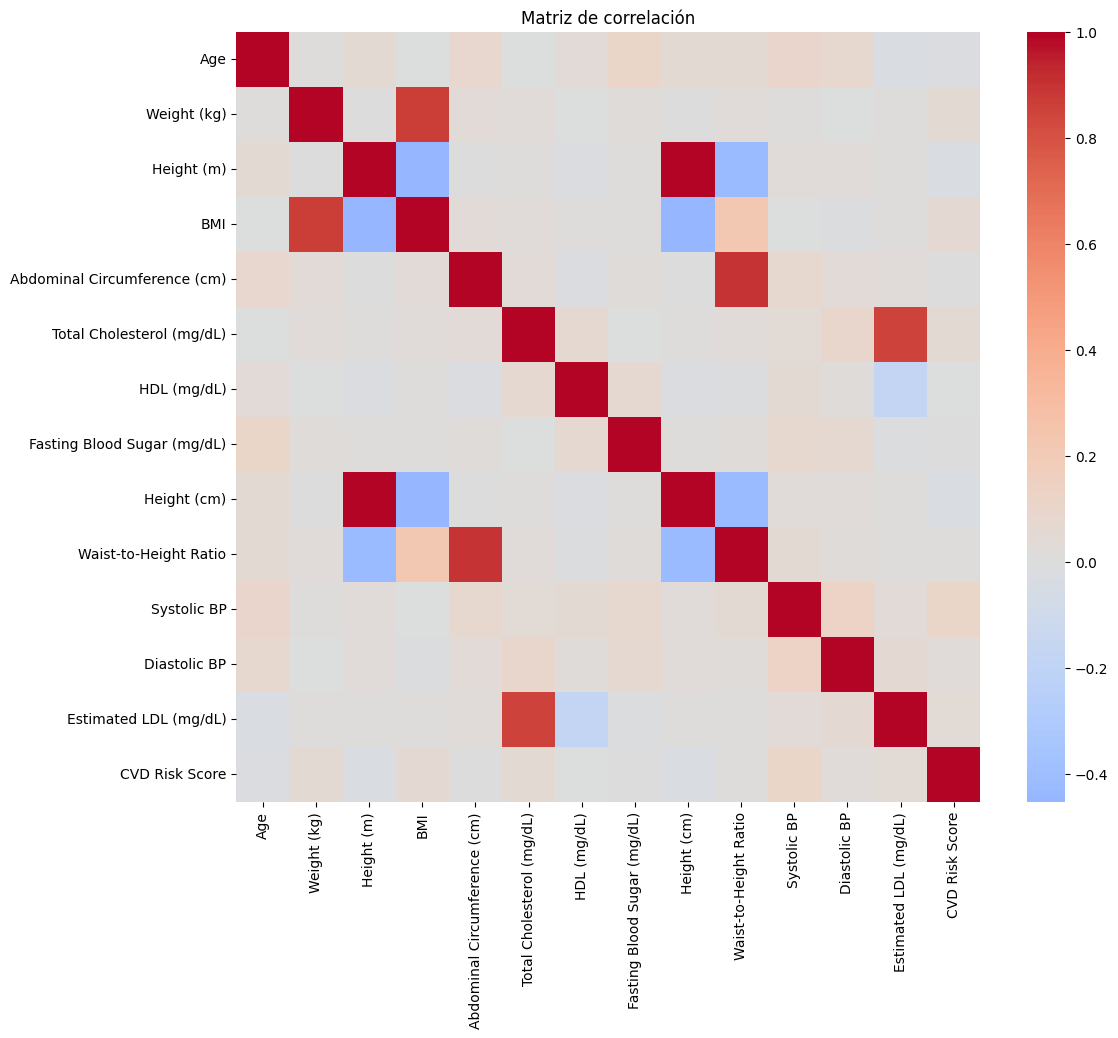

In [366]:
corr_matrix = data.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

A partir de la matriz de correlación se identifican relaciones fuertes entre variables que representan la misma magnitud o que son derivadas entre sí. En particular se observan los siguientes patrones:

- Correlación casi perfecta entre Height (m) y Height (cm), lo cual es esperable dado que son la misma variable en distintas unidades.

- Alta correlación entre Weight (kg) y BMI, lo que se explica porque el BMI se calcula directamente a partir del peso y la altura.

- Alta correlación entre Waist-to-Height Ratio y Abdominal Circumference (cm), ya que el ratio se deriva directamente de esta variable y la altura.

- Alta correlación entre Total Cholesterol (mg/dL) y Estimated LDL (mg/dL).

- Correlación considerable entre Systolic BP y Diastolic BP.

Estos patrones indican presencia de multicolinealidad estructural, es decir, variables que contienen información redundante. 

En un modelo de regresión lineal, la multicolinealidad puede generar inestabilidad en los coeficientes, dificultar la interpretación y reducir la capacidad predictiva efectiva. Entonces, se decide eliminar variables que son transformaciones directas de otras, conservar las que tienen significado clínico primario y evitar duplicidad de información.

- Se elimina Height (cm) y se conserva Height (m), dado que ambas contienen exactamente la misma información.

- Sin embargo, se decide conservar BMI y eliminar Weight (kg) y Height (m) ya que BMI integra ambas variables.

- Dado que Waist-to-Height Ratio es una transformación directa de Abdominal Circumference y Height, y representa una medida estandarizada del riesgo metabólico, se conserva únicamente el ratio. Se elimina Abdominal Circumference (cm).

- Se observa alta correlación entre Total Cholesterol y Estimated LDL. Dado que LDL es un componente del colesterol total y suele ser un predictor más específico del riesgo cardiovascular, se conserva Estimated LDL y se elimina Total Cholesterol.

- Aunque Systolic y Diastolic están correlacionadas, no son redundantes clínicamente. Ambas aportan información distinta sobre la presión arterial. Por lo tanto, se conservan ambas.

Entonces, las variables numéricas que finalmente se propone conservar son: Age, BMI, Waist-to-Height Ratio, Systolic BP, Diastolic BP, Estimated LDL, HDL, Fasting Blood Sugar.

Además, las categóricas que se conservan son: Sex, Smoking Status, Diabetes Status, Physical Activity Level, Family History of CVD.


In [367]:
columnas_a_eliminar = [
    "Patient ID",
    "Date of Service",
    "Blood Pressure (mmHg)",
    "CVD Risk Level",
    "Height (m)",
    "Height (cm)",
    "Weight (kg)",
    "Abdominal Circumference (cm)",
    "Total Cholesterol (mg/dL)"
]

data_modelo2 = data.drop(columns=columnas_a_eliminar)

print("Shape después del filtrado:", data_modelo2.shape)

Shape después del filtrado: (1349, 15)


Ahora, volvemos a separar en train y test, aplicar los pipelines, entrenar los modelos y evaluar su desempeño:

In [368]:
TARGET = "CVD Risk Score"

X2 = data_modelo2.drop(columns=[TARGET])
y2 = data_modelo2[TARGET]

print("X shape:", X2.shape)
print("y shape:", y2.shape)

X shape: (1349, 14)
y shape: (1349,)


In [369]:
from sklearn.model_selection import train_test_split

X_train_modelo2, X_test_modelo2, y_train2, y_test2 = train_test_split(
    X2, y2,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train_modelo2.shape)
print("Test:", X_test_modelo2.shape)

Train: (1011, 14)
Test: (338, 14)


In [370]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

selector_num2 = make_column_selector(dtype_include=np.number)
selector_cat2 = make_column_selector(dtype_include=object)

pipeline_numerico2 = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

pipeline_categorico2 = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador2 = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico2, selector_num2),
        ("cat", pipeline_categorico2, selector_cat2),
    ],
    remainder="drop"
)

In [371]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

resultados2 = []

# Baseline (fase 2)
pred_baseline2 = np.full_like(y_test2, y_train2.mean())

resultados2.append({
    "Modelo": "Baseline (media)",
    "RMSE": np.sqrt(mean_squared_error(y_test2, pred_baseline2)),
    "MAE": mean_absolute_error(y_test2, pred_baseline2),
    "R2": r2_score(y_test2, pred_baseline2)
})

mejor_rmse2 = np.inf
mejor_modelo2 = None
mejor_nombre2 = None

for nombre, modelo in modelos_lineales2.items():

    pipeline_modelo2 = Pipeline(steps=[
        ("preprocesamiento", preprocesador2),
        ("modelo", modelo)
    ])

    pipeline_modelo2.fit(X_train_modelo2, y_train2)
    pred_test2 = pipeline_modelo2.predict(X_test_modelo2)

    rmse2 = np.sqrt(mean_squared_error(y_test2, pred_test2))
    mae2  = mean_absolute_error(y_test2, pred_test2)
    r22   = r2_score(y_test2, pred_test2)

    resultados2.append({
        "Modelo": nombre,
        "RMSE": rmse2,
        "MAE": mae2,
        "R2": r22
    })

    # guardar el mejor modelo de la fase 2
    if rmse2 < mejor_rmse2:
        mejor_rmse2 = rmse2
        mejor_modelo2 = pipeline_modelo2
        mejor_nombre2 = nombre

tabla_resultados2 = pd.DataFrame(resultados2).sort_values("RMSE")
print("Mejor modelo fase 2:", mejor_nombre2, "RMSE:", mejor_rmse2)

tabla_resultados2

Mejor modelo fase 2: Lasso RMSE: 8.179515314485808


,Modelo,RMSE,MAE,R2
3,Lasso,8.179515,3.083327,0.026371
4,ElasticNet,8.191450,3.105132,0.023528
2,Ridge,8.244391,3.248090,0.010865
1,LinearRegression,8.245051,3.250329,0.010707
0,Baseline (media),8.311631,3.527029,-0.005335


La ingeniería de características basada en multicolinealidad (eliminación de variables redundantes y conservación de un subconjunto clínicamente relevante) sí mejoró el desempeño en el conjunto de prueba respecto al enfoque original. En el enfoque sin ingeniería de características, el mejor modelo fue Lasso (α = 0.1) con métricas:
- RMSE = 8.203817
- MAE = 3.071617
- R² = 0.020577

Tras aplicar la selección de características y reconstruir el preprocesamiento, el mejor modelo volvió a ser Lasso (α = 0.1), pero con un mejor rendimiento en test:

- RMSE = 8.179515
- MAE = 3.083327
- R² = 0.026371

Dado que el objetivo del laboratorio es maximizar desempeño en test y producir predicciones sobre los datos no etiquetados, se define como modelo final el Lasso obtenido después de la ingeniería de características, ya que presenta menor error y mayor capacidad explicativa.

## 3.3. Modelo Final

Como en la etapa de ingeniería de características se sobrescribieron X_train_modelo, X_test_modelo, y_train, y_test y/o el preprocesador, aquí se deja el bloque para reconstruir y re-ejecutar el modelo final (Lasso) usando el pipeline previo (imputación + clipping + one-hot) y recalcular las métricas de forma consistente.

In [372]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

modelo_final = Pipeline(steps=[
    ("preprocesamiento", preprocesador2),
    ("modelo", Lasso(alpha=0.1, max_iter=10000))
])

modelo_final.fit(X_train_modelo2, y_train2)

pred_test2 = modelo_final.predict(X_test_modelo2)

rmse2 = np.sqrt(mean_squared_error(y_test2, pred_test2))
mae2  = mean_absolute_error(y_test2, pred_test2)
r22   = r2_score(y_test2, pred_test2)

print("Modelo final (Fase 2 - Lasso α=0.1)")
print("RMSE:", rmse2)
print("MAE :", mae2)
print("R2  :", r22)

Modelo final (Fase 2 - Lasso α=0.1)
RMSE: 8.179515314485808
MAE : 3.0833271805754507
R2  : 0.026371037829686528


# 4. Analisis Cualitativo
## 4.1. Importancia de Variables
Una vez definido el modelo final como una regresión lineal con regularización L1 (Lasso, α = 0.1) entrenada sobre el conjunto de datos posterior a la ingeniería de características, se procede a analizar la importancia de las variables.

En modelos lineales, la interpretación se basa directamente en los coeficientes estimados. Cada coeficiente representa el cambio esperado en el CVD Risk Score ante un incremento unitario de la variable correspondiente, manteniendo constantes las demás variables. Sin embargo, dado que el modelo incluye variables numéricas transformadas y variables categóricas codificadas mediante one-hot encoding, la interpretación debe hacerse con cuidado.

En el caso del modelo Lasso, la importancia de cada variable se puede medir como el valor absoluto de su coeficiente:

Cuanto mayor sea |β|, mayor es la influencia de la variable en la predicción.

Si un coeficiente es exactamente 0, la variable fue eliminada automáticamente por la regularización L1.

Esto permite no solo medir importancia, sino también identificar qué variables fueron efectivamente seleccionadas por el modelo.

El siguiente bloque extrae los nombres finales de las variables después del preprocesamiento (incluyendo las columnas generadas por one-hot encoding), obtiene los coeficientes del modelo Lasso y construye una tabla ordenada por importancia absoluta.

In [373]:
import numpy as np
import pandas as pd

# Extraer el preprocesador ya entrenado
prep_fit = modelo_final.named_steps["preprocesamiento"]

# Obtener nombres finales de las variables transformadas
feature_names = prep_fit.get_feature_names_out()

# Extraer el modelo Lasso entrenado
lasso = modelo_final.named_steps["modelo"]

# Coeficientes estimados
coefs = lasso.coef_

# Construir tabla de importancia
tabla_importancia = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coefs,
    "Importancia_abs": np.abs(coefs)
}).sort_values("Importancia_abs", ascending=False)

tabla_importancia.head(25)

,Variable,Coeficiente,Importancia_abs
12,cat__Diabetes Status_N,-2.297010e+00,2.297010e+00
5,num__Systolic BP,1.161411e+00,1.161411e+00
10,cat__Smoking Status_N,-9.696676e-01,9.696676e-01
15,cat__Physical Activity Level_Low,-9.139552e-01,9.139552e-01
22,cat__Blood Pressure Category_Normal,-8.802041e-01,8.802041e-01
17,cat__Family History of CVD_N,8.446844e-01,8.446844e-01
1,num__BMI,5.875688e-01,5.875688e-01
0,num__Age,-4.211760e-01,4.211760e-01
20,cat__Blood Pressure Category_Hypertension Stage 1,2.431415e-01,2.431415e-01
4,num__Waist-to-Height Ratio,-1.640453e-01,1.640453e-01


In [374]:
seleccionadas = tabla_importancia[
    tabla_importancia["Importancia_abs"] > 1e-8
].copy()

print("Total features generadas:", tabla_importancia.shape[0])
print("Variables seleccionadas por Lasso:", seleccionadas.shape[0])

seleccionadas.head(25)

Total features generadas: 23
Variables seleccionadas por Lasso: 12


,Variable,Coeficiente,Importancia_abs
12,cat__Diabetes Status_N,-2.297010,2.297010
5,num__Systolic BP,1.161411,1.161411
10,cat__Smoking Status_N,-0.969668,0.969668
15,cat__Physical Activity Level_Low,-0.913955,0.913955
22,cat__Blood Pressure Category_Normal,-0.880204,0.880204
17,cat__Family History of CVD_N,0.844684,0.844684
1,num__BMI,0.587569,0.587569
0,num__Age,-0.421176,0.421176
20,cat__Blood Pressure Category_Hypertension Stage 1,0.243142,0.243142
4,num__Waist-to-Height Ratio,-0.164045,0.164045


El análisis de importancia de variables del modelo final (Lasso, α = 0.1) muestra que la regularización L1 realizó una selección efectiva de predictores, concentrando el peso del modelo en un conjunto reducido de variables clínicamente relevantes y anulando otras cuyo aporte marginal es prácticamente nulo. Esto se observa en la presencia de múltiples coeficientes exactamente iguales a cero, lo que indica que el modelo descartó automáticamente aquellas variables que no mejoraban la capacidad predictiva una vez consideradas las demás.

La variable con mayor magnitud absoluta del coeficiente es Diabetes Status_N (−2.30). Esto indica que, en comparación con la categoría de referencia, no presentar diabetes se asocia con una disminución importante en el riesgo estimado. Desde el punto de vista clínico, esto es coherente: la diabetes es uno de los factores de riesgo cardiovascular más robustamente documentados. El modelo está capturando esa relación estructural dentro de los datos disponibles.

En segundo lugar, aparece Systolic BP (1.16) como la variable numérica más influyente. El signo positivo indica que, a mayor presión sistólica, mayor es el riesgo predicho de enfermedad cardiovascular. Esta relación es consistente con la evidencia médica, donde la hipertensión arterial es uno de los principales determinantes del riesgo cardiovascular. La relevancia de esta variable refuerza la coherencia clínica del modelo.

También destacan variables relacionadas con comportamiento y antecedentes: Smoking Status_N (−0.97) y Physical Activity Level_Low (−0.91). En el primer caso, no fumar se asocia con menor riesgo estimado respecto a la categoría de referencia. En el segundo, el bajo nivel de actividad física muestra una contribución relevante en el modelo, lo que es consistente con la literatura sobre sedentarismo y riesgo cardiometabólico. Asimismo, Family History of CVD_N (0.84) indica que la presencia o ausencia de antecedentes familiares influye de manera importante en la predicción.

Entre las variables antropométricas, BMI (0.59) presenta un coeficiente positivo, lo que implica que mayores valores del índice de masa corporal incrementan el riesgo estimado. Esta relación es clínicamente esperable, dado el vínculo entre obesidad, síndrome metabólico y enfermedad cardiovascular. De igual forma, Waist-to-Height Ratio (−0.16) aparece con menor magnitud, lo que sugiere que su contribución es secundaria frente a otras variables más determinantes.

En cuanto a variables lipídicas, Estimated LDL (0.12) conserva un coeficiente distinto de cero, aunque con menor impacto relativo. Esto indica que el colesterol LDL aporta señal predictiva, pero su influencia es menor comparada con presión sistólica, diabetes o tabaquismo dentro del marco lineal del modelo.

Es relevante notar que múltiples variables quedaron con coeficiente exactamente cero: HDL, Diastolic BP, Fasting Blood Sugar, Sex, Physical Activity Level_High, Diabetes Status_Y, Blood Pressure Category_Elevated, entre otras. Esto significa que, bajo penalización L1, estas variables no aportan información adicional significativa una vez consideradas las demás. La eliminación automática confirma la presencia de redundancia o baja relevancia marginal en el contexto del modelo lineal.

En conjunto, el patrón observado es coherente con los determinantes clásicos del riesgo cardiovascular: presión arterial, diabetes, tabaquismo, obesidad, antecedentes familiares y perfil lipídico. Sin embargo, el bajo R² del modelo indica que, aunque las variables seleccionadas son clínicamente plausibles, la capacidad explicativa global sigue siendo limitada. Esto sugiere que la relación entre los predictores disponibles y el CVD Risk Score no es fuertemente lineal o que existen factores no observados que influyen de manera relevante en el riesgo cardiovascular.

## 4.2. Análisis de Resultados

### ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

El mejor modelo seleccionado fue **Lasso (α = 0.1)** entrenado sobre el conjunto posterior a la ingeniería de características. Este modelo aplica regularización L1, lo que implica que algunos coeficientes son exactamente cero (variables descartadas automáticamente).

Los coeficientes más relevantes obtenidos fueron:

- **Diabetes Status_N:** −2.297  
- **Systolic BP:** 1.161  
- **Smoking Status_N:** −0.970  
- **Physical Activity Level_Low:** −0.914  
- **Blood Pressure Category_Normal:** −0.880  
- **Family History of CVD_N:** 0.845  
- **BMI:** 0.588  
- **Age:** −0.421  
- **Blood Pressure Category_Hypertension Stage 1:** 0.243  
- **Waist-to-Height Ratio:** −0.164  
- **Estimated LDL:** 0.116  

Varias variables quedaron con coeficiente igual a cero (HDL, Diastolic BP, Fasting Blood Sugar, Sex, entre otras), lo que confirma la selección automática realizada por Lasso.

---

### ¿Cuál modelo ofrece el mejor rendimiento en test? ¿Cómo interpretar las métricas?

Según la tabla comparativa, el mejor modelo fue:

**Lasso (α = 0.1)**

- **RMSE = 8.179515**  
- **MAE = 3.083327**  
- **R² = 0.026371**

Este modelo superó a Ridge, ElasticNet, LinearRegression y al baseline.

#### Interpretación de métricas

**RMSE (Root Mean Squared Error)**  
Mide el error promedio penalizando más los errores grandes. El valor aproximado de 8.18 indica que, en promedio, las predicciones se desvían alrededor de 8 unidades del CVD Risk Score real.

**MAE (Mean Absolute Error)**  
Representa el error promedio absoluto (~3.08). Es menos sensible a valores extremos que el RMSE y facilita la interpretación directa del error promedio.

**R² (Coeficiente de determinación)**  
El valor 0.026 indica que el modelo explica aproximadamente 2.6% de la variabilidad del CVD Risk Score. Aunque es bajo, es superior al baseline y a los demás modelos lineales evaluados.

En conjunto, el modelo presenta capacidad predictiva limitada, pero consistente con la naturaleza compleja y multifactorial del riesgo cardiovascular.

---

### ¿Qué variables fueron seleccionadas y qué implicaciones tienen?

El modelo seleccionó principalmente variables relacionadas con:

- Diabetes  
- Presión arterial sistólica  
- Tabaquismo  
- Actividad física  
- Antecedentes familiares  
- BMI  
- Perfil lipídico (LDL)

#### Interpretación clínica

La importancia de **Diabetes** y **Systolic BP** es coherente con la literatura médica, ya que ambos son factores determinantes del riesgo cardiovascular.

El **tabaquismo** y el bajo nivel de **actividad física** refuerzan el componente conductual del riesgo.

El **BMI** y el **Waist-to-Height Ratio** reflejan la influencia de la adiposidad y el riesgo metabólico asociado.

Las variables descartadas (HDL, Diastolic BP, Sex, entre otras) no aportaron señal adicional una vez consideradas las demás variables en el modelo regularizado.

---

### Implicaciones para toma de decisiones

Este conocimiento podría utilizarse para:

- Priorizar intervenciones en pacientes con hipertensión y diabetes.
- Diseñar estrategias preventivas enfocadas en tabaquismo y actividad física.
- Implementar programas de control de peso y monitoreo de presión arterial.

El modelo confirma que los factores clínicos clásicos siguen siendo los más determinantes dentro del conjunto de datos disponible.

---

## 4.3. Representación matemática del modelo

La regresión lineal puede representarse como:

$$
\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j x_j
$$

donde $\hat{y}$ es el valor predicho del **CVD Risk Score**, $\beta_0$ es el intercepto, $\beta_j$ son los coeficientes asociados a cada variable $x_j$, y $p$ es el número total de variables explicativas.

En este caso se utilizó **Lasso**, que estima los coeficientes resolviendo el siguiente problema de optimización:

$$
\min_{\beta} \left( \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j| \right)
$$

donde:

- El primer término, $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$, corresponde al **error cuadrático total**.
- El segundo término, $\alpha \sum_{j=1}^{p} |\beta_j|$, es la **penalización L1**.
- $\alpha$ controla la intensidad de la regularización.
- $n$ es el número de observaciones.

La penalización L1 tiene la propiedad de forzar algunos coeficientes exactamente a cero, realizando selección automática de variables.

El modelo se resolvió mediante el algoritmo de **coordinate descent**, implementado en `scikit-learn`, ajustando el modelo sobre el conjunto de entrenamiento y evaluando su desempeño en el conjunto de prueba.

### Proceso seguido

1. Limpieza y consistencia determinística de los datos.  
2. Eliminación de variables redundantes mediante análisis de colinealidad.  
3. División del dataset en entrenamiento (75%) y prueba (25%).  
4. Preprocesamiento:
   - Imputación de valores faltantes.
   - Escalado de variables numéricas.
   - Codificación one-hot para variables categóricas.
5. Entrenamiento del modelo Lasso.
6. Evaluación en el conjunto de prueba utilizando RMSE, MAE y R².

---

## 4.4. Sesgos que podrían afectar los resultados

### 1. Sesgo de selección

Si la muestra de pacientes no es representativa de la población general (por ejemplo, si proviene de una sola institución, región o segmento demográfico específico), el modelo puede capturar patrones particulares de ese grupo y no generalizar adecuadamente a otras poblaciones. Esto limita la validez externa del modelo.

### 2. Sesgo de medición

Errores sistemáticos en la medición de variables clínicas (por ejemplo, presión arterial mal registrada, errores de digitación o diferencias en protocolos de medición) pueden afectar tanto las variables predictoras como la variable objetivo. Esto puede distorsionar las relaciones estimadas por el modelo y afectar su desempeño real.

Ambos tipos de sesgo pueden influir en la capacidad predictiva del modelo y deben considerarse al interpretar los resultados.

---

## Conclusión

El modelo final seleccionado, Lasso con regularización L1, logró el mejor desempeño dentro de los modelos lineales evaluados. Aunque la capacidad explicativa del modelo es limitada (R² ≈ 0.026), los resultados identifican como variables más relevantes factores clínicamente coherentes con la evidencia médica: diabetes, presión arterial sistólica, tabaquismo, actividad física y obesidad.

Esto sugiere que, si bien el modelo lineal captura parte de la señal presente en los datos, el riesgo cardiovascular es un fenómeno complejo que probablemente requiere variables adicionales o modelos no lineales para mejorar su capacidad predictiva. Sin embargo, el análisis permite extraer conocimiento útil para priorizar intervenciones preventivas y comprender los principales determinantes del riesgo en el conjunto de datos estudiado.


# 5. Exportar a HTML

In [375]:
# Instalar nbconvert si no está instalado
!pip install -q nbconvert

# Nombre del notebook
notebook = "main.ipynb"

# Exportar a HTML
!jupyter nbconvert --to html "$notebook"


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[NbConvertApp] Converting notebook main.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1193400 bytes to main.html
